![display relevant image here](https://stock.adobe.com/search?k=%22financial+logo%22)
- Banner/header image

# Title
-  Financial Loan Approval Risk Analysis

## Overview

Project Overview

In this project, I use the CRISP-DM framework to build a machine learning model for loan approval.

My main goal is to use past loan applications to predict whether an application was historically approved or not. I chose classification because LoanApproved is a binary target.I also used simple linear regression and multiple linear regression as my base models.

I will go through these main steps:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Conclusion and recommendations

The project brief gives two important business costs:

- False denial of a creditworthy applicant: $8,000
- False approval of a borrower who defaults: $50,000

I will use these figures in a business-cost proxy. This is only a proxy because the dataset target is LoanApproved, not actual loan default.

### Main approach

I will compare six classification models:

- simple linear regression(baseline model)
- multiple linear regresion(baseline model)
- Logistic Regression
- Decision Tree
- Random Forest
- AdaBoost
- Gradient Boosting
- XGBoost
- Support Vector Machine(svm)
- KNN

I will use a ColumnTransformer and Pipeline so that the preprocessing and modelling steps are kept together and applied consistently.

## Business Understanding



 1. Business problem

The current loan approval process depends heavily on manual review by loan officers. According to the project brief, this can make decisions slower and less consistent.A machine learning model can help with the first stage of screening. The final decision can still be reviewed by a loan officer.

2. Stakeholders

- Loan officers: They need useful and understandable predictions.
- Management:They want faster processing and lower financial losses.
- Customers:They need timely and consistent decisions.
- Risk and compliance team:they need a model that can be explained and monitored.
- Data and engineering team:They need a reproducible pipeline.

3. Cost of model errors

The project gives two different costs:
- A false denial can mean about $8,000 in lost profit.
- A false approval can mean about $50,000 in losses if the borrower defaults.

This means the two types of errors do not have the same cost.

For this project, I used:
Business cost = (False Positives * $50,000) + (False Negatives * $8000)

This is only an indirect measure because LoanApproved is the target and not actual default.

4.  Why I chose classification;

I used simple linear regression and multiple linear regression models as my baseline models but they are not the ideal models since I am working with binary as my target variable

I chose classification because LoanApproved contains two classes: 0 and 1.

Classification also allows me to use a confusion matrix, precision, recall, F1-score and ROC-AUC.

5. Success criteria

I will mainly look at:

- ROC-AUC: how well the model separates the two classes.
- Recall: how many positive approval cases are correctly identified.
- Precision: how many predicted approvals are actually approvals in the historical data.
- F1-score: balance between precision and recall.

These are my metrics targets:

- ROC-AUC ≥ 0.80
- Recall ≥ 0.90
- Precision ≥ 0.90



## Data Understanding

The project brief states that the dataset contains 20,000 historical loan applications and a mixture of numerical and categorical variables.

What I need to understand:

- Preview the dataset
- the size and structure of the data
- the data types
- the duplicates
- missing values
- the target distribution
- the distributions of important variables
- relationships between variables
- possible outliers and data quality problems




In [146]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, chi2_contingency

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    KFold,
    cross_validate,
    GridSearchCV
)
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.neighbors import KNeighborsClassifier


import warnings
warnings.filterwarnings("ignore")


In [147]:
#Load the dataset
df = pd.read_csv('financial_loan_data.csv')

In [148]:
# EDA Code Here - Create New Cells As Needed
# Previewing the dataset
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


I will have to clean AnnualIncome and restructure how the column names are named

In [149]:
#checking the size and structure of the data
df.shape

(20000, 35)

There are 20,000 rows and 35 columns

In [150]:
# Checking the data types and structure of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

The dataset contains numerical and categorical variables. AnnualIncome is stored as an object, even though income should be numerical.

In [151]:
# Checking for duplicate rows
df.duplicated().sum()

np.int64(0)

In [152]:
# Checking for the total missing values
df.isnull().sum().sum()

np.int64(2804)

In [153]:
# Checking missing values, sorted from highest to lowest
missing = df.isna().sum().sort_values(ascending=False)

missing

,0
MaritalStatus,1331
EducationLevel,901
SavingsAccountBalance,572
CreditScore,0
AnnualIncome,0
Age,0
Experience,0
LoanAmount,0
LoanDuration,0
NumberOfDependents,0


In [154]:
# Calculating the percentage of missing values
missing_pct = (missing / len(df) * 100).round(2)

missing_pct

,0
MaritalStatus,6.65
EducationLevel,4.50
SavingsAccountBalance,2.86
CreditScore,0.00
AnnualIncome,0.00
Age,0.00
Experience,0.00
LoanAmount,0.00
LoanDuration,0.00
NumberOfDependents,0.00


In [155]:
# Creating a table showing missing counts and percentages
missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_pct
})

missing_table

,missing_count,missing_percent
MaritalStatus,1331,6.65
EducationLevel,901,4.50
SavingsAccountBalance,572,2.86
CreditScore,0,0.00
AnnualIncome,0,0.00
Age,0,0.00
Experience,0,0.00
LoanAmount,0,0.00
LoanDuration,0,0.00
NumberOfDependents,0,0.00


In [156]:
# Displaying only columns that have missing values
display(missing_table[missing_table["missing_count"] > 0])

,missing_count,missing_percent
MaritalStatus,1331,6.65
EducationLevel,901,4.50
SavingsAccountBalance,572,2.86


Marital status has the highest number of missing values of 1331 followed by educationallevel 901 then savingsaccountbalance with 572

In [157]:
# Checking the unique values of LoanApproved
df["LoanApproved"].unique()

array([0, 1])

The target variable contains 0 and 1 ,this confirms that the main machine learning problem is a binary classification.

In [158]:
# Checking the distribution of the target variable
print("Target distribution:")

display(
    df["LoanApproved"]
    .value_counts()
    .rename_axis("LoanApproved")
    .to_frame("count")
)

Target distribution:


,count
LoanApproved,
0,15220
1,4780


In [159]:
# Checking the target distribution as percentages
display(
    (df["LoanApproved"].value_counts(normalize=True) * 100)
    .round(2)
    .rename_axis("LoanApproved")
    .to_frame("percent")
)

,percent
LoanApproved,
0,76.1
1,23.9


The dataset is imbalanced, with 0 (Not Approved) representing 76.1% of the observations and 1 (Approved) representing 23.9%.Because the classes are not equal, accuracy alone may give an incomplete picture of model performance.




In [160]:
# Rename columns to snake_case

df.columns = (
    df.columns
    .str.replace(r'(?<!^)(?=[A-Z])', '_', regex=True)
    .str.title()
)

print(df.columns.tolist())

['Age', 'Annual_Income', 'Credit_Score', 'Employment_Status', 'Education_Level', 'Experience', 'Loan_Amount', 'Loan_Duration', 'Marital_Status', 'Number_Of_Dependents', 'Home_Ownership_Status', 'Monthly_Debt_Payments', 'Credit_Card_Utilization_Rate', 'Number_Of_Open_Credit_Lines', 'Number_Of_Credit_Inquiries', 'Debt_To_Income_Ratio', 'Bankruptcy_History', 'Loan_Purpose', 'Previous_Loan_Defaults', 'Payment_History', 'Length_Of_Credit_History', 'Savings_Account_Balance', 'Checking_Account_Balance', 'Total_Assets', 'Total_Liabilities', 'Monthly_Income', 'Utility_Bills_Payment_History', 'Job_Tenure', 'Net_Worth', 'Base_Interest_Rate', 'Interest_Rate', 'Monthly_Loan_Payment', 'Total_Debt_To_Income_Ratio', 'Loan_Approved', 'Risk_Score']


In [161]:
# Checking the AnnualIncome column
df["Annual_Income"].head()

,Annual_Income
0,"$39,948.00"
1,"$39,709.00"
2,"$40,724.00"
3,"$69,084.00"
4,"$103,264.00"


In [162]:
# Clean AnnualIncome

df["Annual_Income"] = (
    df["Annual_Income"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["Annual_Income"] = pd.to_numeric(
    df["Annual_Income"],
    errors="coerce"
)
print("Annual_Income data type:", df["Annual_Income"].dtype)
display(df["Annual_Income"].head())


Annual_Income data type: float64


,Annual_Income
0,39948.0
1,39709.0
2,40724.0
3,69084.0
4,103264.0


I cleaned AnnualIncome by removing the $ sign and commas and converting it to a numeric column.I did this during data understanding to enable me to visualize.

In [163]:
# Identifying numerical predictor variables
numeric_features = df.drop(columns=["Loan_Approved"]).select_dtypes(include=np.number).columns.tolist()

numeric_features

['Age',
 'Annual_Income',
 'Credit_Score',
 'Experience',
 'Loan_Amount',
 'Loan_Duration',
 'Number_Of_Dependents',
 'Monthly_Debt_Payments',
 'Credit_Card_Utilization_Rate',
 'Number_Of_Open_Credit_Lines',
 'Number_Of_Credit_Inquiries',
 'Debt_To_Income_Ratio',
 'Previous_Loan_Defaults',
 'Payment_History',
 'Length_Of_Credit_History',
 'Savings_Account_Balance',
 'Checking_Account_Balance',
 'Total_Assets',
 'Total_Liabilities',
 'Monthly_Income',
 'Utility_Bills_Payment_History',
 'Job_Tenure',
 'Net_Worth',
 'Base_Interest_Rate',
 'Interest_Rate',
 'Monthly_Loan_Payment',
 'Total_Debt_To_Income_Ratio',
 'Risk_Score']

In [164]:
# Checking the number of numerical features
print("Numerical features:", len(numeric_features))

Numerical features: 28


In [165]:
# Identifying categorical predictor variables
categorical_features= df.drop(columns=["Loan_Approved"]).select_dtypes(include="object").columns.tolist()

categorical_features

['Employment_Status',
 'Education_Level',
 'Marital_Status',
 'Home_Ownership_Status',
 'Bankruptcy_History',
 'Loan_Purpose']

In [166]:
# Checking the number of categorical features
print("Categorical features:", len(categorical_features))

Categorical features: 6


In [167]:
# Checking summary statistics
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,20000.0,NaN,NaN,NaN,39.7526,11.622713,18.0,32.0,40.0,48.0,80.0
Annual_Income,20000.0,NaN,NaN,NaN,59161.47355,40350.845168,15000.0,31679.0,48566.0,74391.0,485341.0
Credit_Score,20000.0,NaN,NaN,NaN,571.6124,50.997358,343.0,540.0,578.0,609.0,712.0
Employment_Status,20000,3,Employed,17036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education_Level,19099,5,Bachelor,5804,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience,20000.0,NaN,NaN,NaN,17.52275,11.316836,0.0,9.0,17.0,25.0,61.0
Loan_Amount,20000.0,NaN,NaN,NaN,24882.8678,13427.421217,3674.0,15575.0,21914.5,30835.0,184732.0
Loan_Duration,20000.0,NaN,NaN,NaN,54.057,24.664857,12.0,36.0,48.0,72.0,120.0
Marital_Status,18669,4,Married,9370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number_Of_Dependents,20000.0,NaN,NaN,NaN,1.5173,1.386325,0.0,0.0,1.0,2.0,5.0


The data set has 6 categorical variable and 28 numerical variables

# Data understanding summary

I previewed the dataset, there are 20,000rows and 35 columns.There are zero duplicates and 2804 total missing values with marital status having the highest total number of missing values of 1331, followed by education level with 901 and finally with savings account balance with 572.I also checked for unique values under loan approved and their percentage distribution, where loan not approved have the highest percentage of 76.1% and loan aapproved having 23.9%.I separated the variables into numerical and categorical groups and looked at summary statistics.I also converted the  AnnualIncome  from text to a number and also cleaned it before modelling .

# Feature understanding

The dataset contains numerical financial variables and categorical applicant information.

Some examples of numerical variables are:
The dataset has 28 numerical variables

- Age
- AnnualIncome
- CreditScore
- LoanAmount
- DebtToIncomeRatio
- MonthlyIncome
- RiskScore

Some categorical variables include:
The dataset has 6 categorical variables

- EmploymentStatus
- EducationLevel
- MaritalStatus
- HomeOwnershipStatus
- LoanPurpose

AnnualIncome is stored as currency text, so I converted it to a numeric value.There are also 2804 missing values




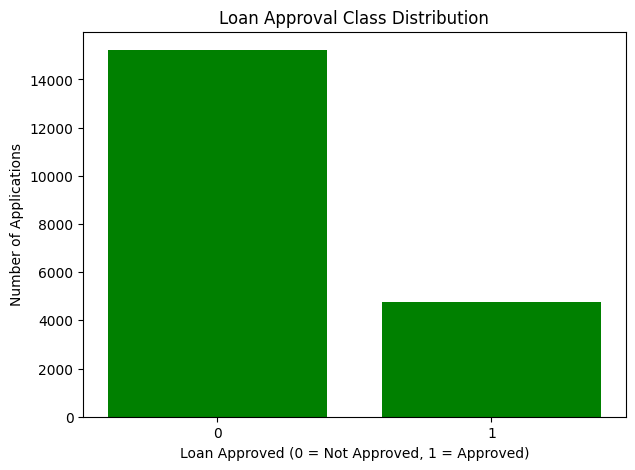

In [168]:
# Visualization 1: Target distribution

plt.figure(figsize=(7, 5))

# Counting approved and not approved applications
counts = df["Loan_Approved"].value_counts().sort_index()

# Creating the bar chart
plt.bar(counts.index.astype(str), counts.values, color="green")

# Adding labels and title
plt.title("Loan Approval Class Distribution")
plt.xlabel("Loan Approved (0 = Not Approved, 1 = Approved)")
plt.ylabel("Number of Applications")

plt.show()

This bar chart plots the number of approved and not_approved applications. The graph shows that the not-approved group is much larger than the approved group. This confirms the class imbalance found in the percentage table.


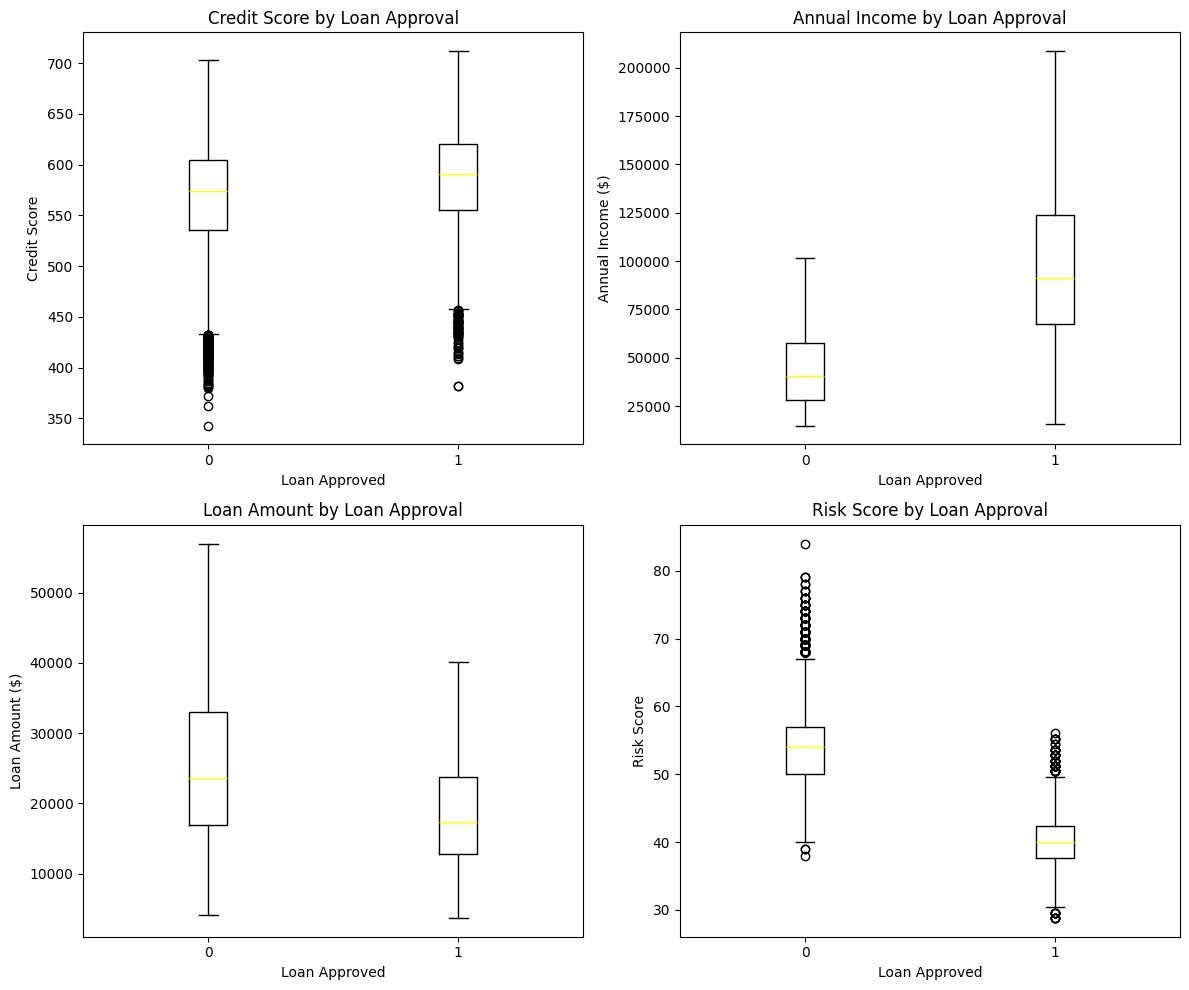

In [169]:
# Set 1: Numerical variables by loan approval

plt.figure(figsize=(12, 10))

# 1. Credit Score
plt.subplot(2, 2, 1)

groups = [
    df.loc[df["Loan_Approved"] == 0, "Credit_Score"],
    df.loc[df["Loan_Approved"] == 1, "Credit_Score"]
]

plt.boxplot(
    groups,
    labels=["0", "1"],
    medianprops=dict(color="yellow")
)

plt.title("Credit Score by Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Credit Score")


# 2. Annual Income
plt.subplot(2, 2, 2)

groups = [
    df.loc[df["Loan_Approved"] == 0, "Annual_Income"],
    df.loc[df["Loan_Approved"] == 1, "Annual_Income"]
]

plt.boxplot(
    groups,
    labels=["0", "1"],
    showfliers=False,
    medianprops=dict(color="yellow")
)

plt.title("Annual Income by Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Annual Income ($)")


# 3. Loan Amount
plt.subplot(2, 2, 3)

groups = [
    df.loc[df["Loan_Approved"] == 0, "Loan_Amount"],
    df.loc[df["Loan_Approved"] == 1, "Loan_Amount"]
]

plt.boxplot(
    groups,
    labels=["0", "1"],
    showfliers=False,
    medianprops=dict(color="yellow")
)

plt.title("Loan Amount by Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Loan Amount ($)")


# 4. Risk Score
plt.subplot(2, 2, 4)

groups = [
    df.loc[df["Loan_Approved"] == 0, "Risk_Score"],
    df.loc[df["Loan_Approved"] == 1, "Risk_Score"]
]

plt.boxplot(
    groups,
    labels=["0", "1"],
    medianprops=dict(color="yellow")
)

plt.title("Risk Score by Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Risk Score")


plt.tight_layout()
plt.show()

The boxplots compare approved and not-approved applications across four numerical variables. The plots are intended to reveal differences in central tendency, spread and possible outliers between the two historical approval groups.

 The boxplots also help identify possible extreme values.Risk score by loan approval has outliers same to credit score by loan approval


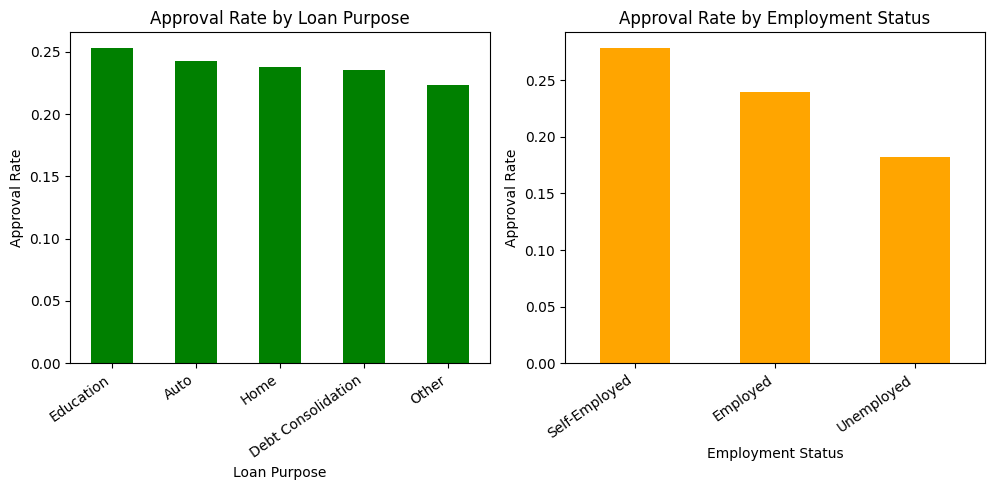

In [170]:
# Set 2: Categorical variables and correlation matrix

plt.figure(figsize=(15, 5))

# 5. Approval rate by loan purpose
plt.subplot(1, 3, 1)

purpose_rate = (
    df.groupby("Loan_Purpose")["Loan_Approved"]
    .mean()
    .sort_values(ascending=False)
)

purpose_rate.plot(kind="bar", color="green")

plt.title("Approval Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Approval Rate")
plt.xticks(rotation=35, ha="right")


# 6. Approval rate by employment status
plt.subplot(1, 3, 2)

employment_rate = (
    df.groupby("Employment_Status")["Loan_Approved"]
    .mean()
    .sort_values(ascending=False)
)

employment_rate.plot(kind="bar", color="orange")

plt.title("Approval Rate by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Approval Rate")
plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.show()

This visualization examines categorical relationships with approval, including approval rate by loan purpose, and also prepares categorical comparisons alongside the numerical analysis. The purpose is to see whether approval rates vary across categories.Hence Education and self_employed have higher chance of loan approval


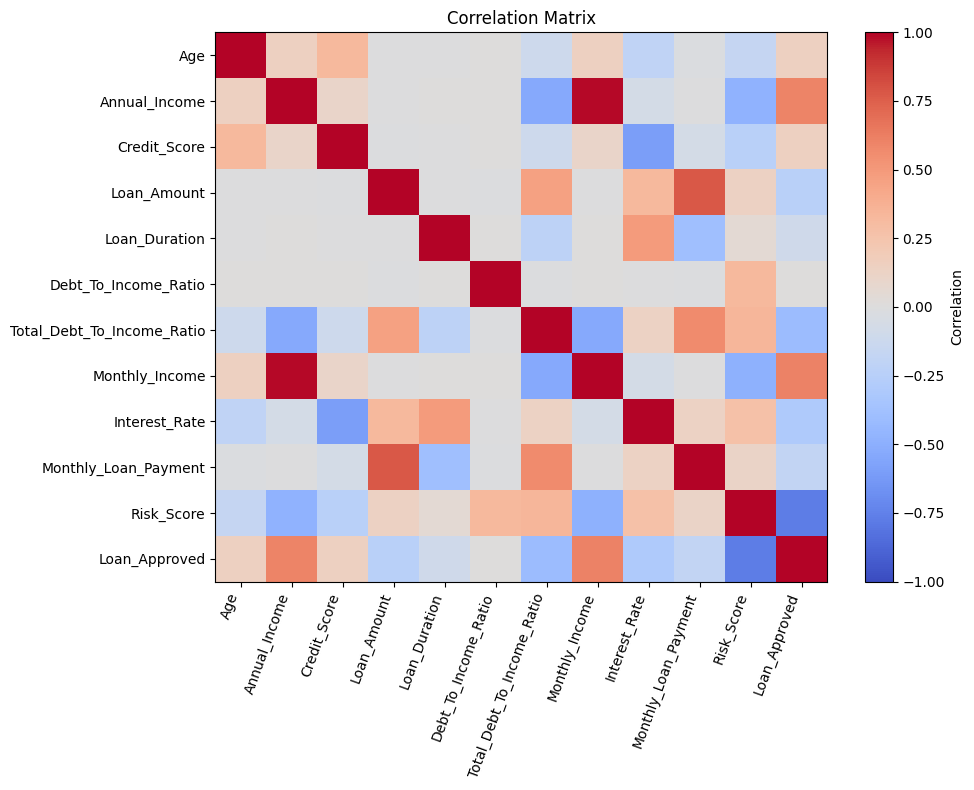

In [171]:
# 7. Correlation Matrix

plt.figure(figsize=(10, 8))

corr_cols = [
    "Age", "Annual_Income", "Credit_Score", "Loan_Amount",
    "Loan_Duration", "Debt_To_Income_Ratio", "Total_Debt_To_Income_Ratio",
    "Monthly_Income", "Interest_Rate", "Monthly_Loan_Payment",
    "Risk_Score", "Loan_Approved"
]

corr_matrix = df[corr_cols].corr()

plt.imshow(
    corr_matrix,
    aspect="auto",
    interpolation="nearest",
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_cols)),
    corr_cols,
    rotation=70,
    ha="right"
)

plt.yticks(
    range(len(corr_cols)),
    corr_cols
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

The correlation matrix shows the direction and strength of linear relationships between selected numerical variables.I use this heatmapcgraph to identify variables that may contain similar information(highly corelated). This is useful when thinking about multicollinearity and feature engineering.

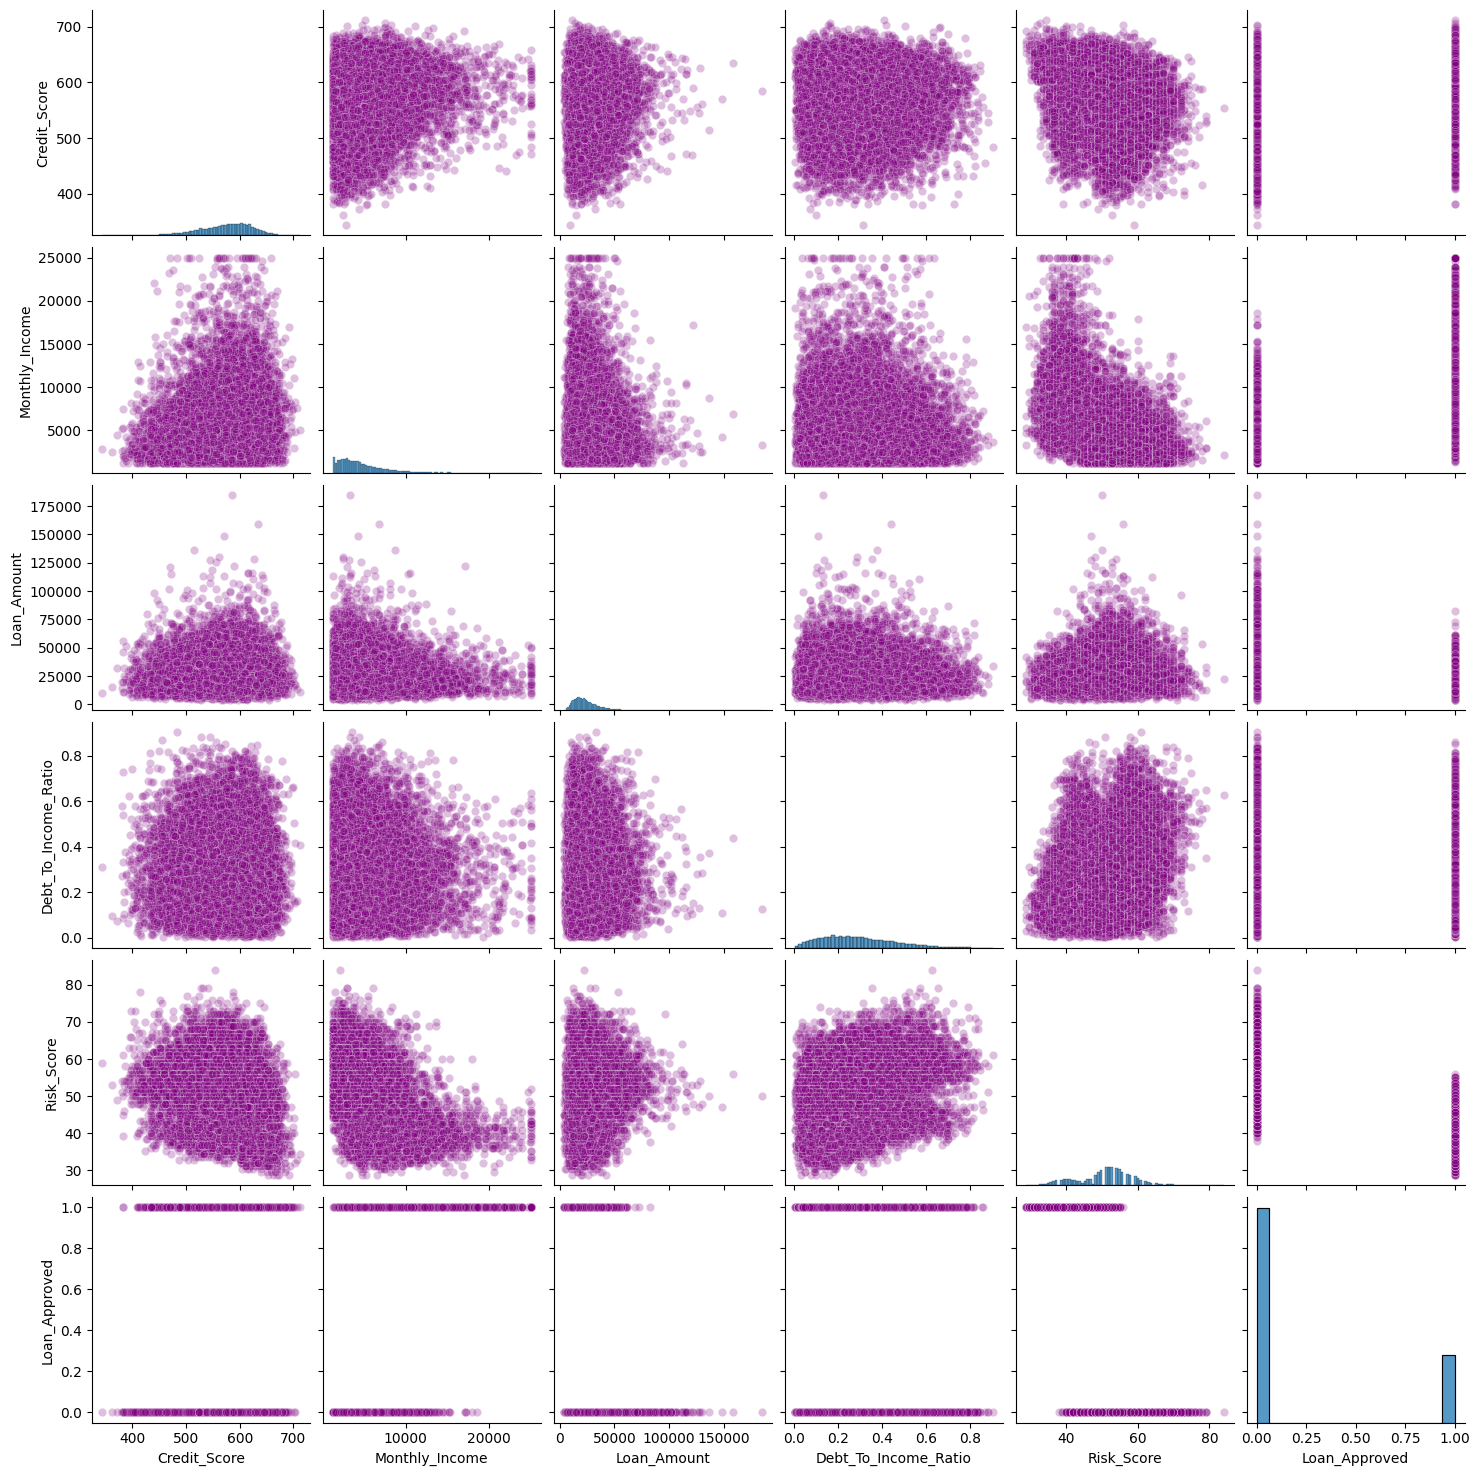

In [172]:
# Additional visualization: Pair Plot

pair_cols = [
    "Credit_Score",
    "Monthly_Income",
    "Loan_Amount",
    "Debt_To_Income_Ratio",
    "Risk_Score",
    "Loan_Approved"
]

pair_data = df[pair_cols]

sns.pairplot(
    pair_data,
    diag_kind="hist",
    plot_kws={"color": "purple", "alpha": 0.25}
)

plt.show()

The pair plot shows relationships of several numerical variables against each other and against the target variable.

### Multivariate visualization summary

The scatter matrix lets me look at several numerical variables together.It gives a broader view of possible relationships, clusters and unusual observations.

In [173]:
# Separate approved and not-approved loans

approved = df[df["Loan_Approved"] == 1]
not_approved = df[df["Loan_Approved"] == 0]

In [174]:
# T-test for numerical variables

test_rows = []

for col in [
    "Credit_Score",
    "Annual_Income",
    "Loan_Amount",
    "Debt_To_Income_Ratio",
    "Risk_Score",
    "Monthly_Income"
]:

    approved_values = approved[col].dropna()
    not_approved_values = not_approved[col].dropna()

    stat, p = ttest_ind(
        approved_values,
        not_approved_values,
        equal_var=False
    )

    test_rows.append([col, stat, p])

In [175]:
# Display t-test results

ttest_results = pd.DataFrame(
    test_rows,
    columns=["feature", "t_statistic", "p_value"]
)

display(ttest_results.sort_values("p_value"))

,feature,t_statistic,p_value
1,Annual_Income,75.080252,0.000000e+00
2,Loan_Amount,-44.143602,0.000000e+00
5,Monthly_Income,76.458650,0.000000e+00
4,Risk_Score,-197.686180,0.000000e+00
0,Credit_Score,20.682430,1.080383e-92
3,Debt_To_Income_Ratio,0.004856,9.961253e-01


The independent-samples t-test shows that Annual_Income, Loan_Amount, Monthly_Income, Risk_Score, and Credit_Score have statistically significant differences between the loan-approved and loan-rejected groups, since their p-values are less than 0.05. However, Debt_To_Income_Ratio does not show a statistically significant difference between the two groups, with a p-value of 0.996. This means that most of the financial and risk-related variables appear to differ between the two loan approval groups. However, the t-test results alone do not mean that these variables will be good predictors, so I will further evaluate them  using the machine-learning models.

In [176]:
# Chi-square test for categorical variables

chi_rows = []

for col in [
    "Employment_Status",
    "Education_Level",
    "Marital_Status",
    "Home_Ownership_Status",
    "Bankruptcy_History",
    "Loan_Purpose"
]:

    table = pd.crosstab(
        df[col].fillna("Missing"),
        df["Loan_Approved"]
    )

    chi2, p, dof, expected = chi2_contingency(table)

    chi_rows.append([col, chi2, dof, p])

In [177]:
# Display chi-square results

chi_results = pd.DataFrame(
    chi_rows,
    columns=["feature", "chi2", "dof", "p_value"]
)

display(chi_results.sort_values("p_value"))

,feature,chi2,dof,p_value
1,Education_Level,1068.927568,5,7.157929e-229
4,Bankruptcy_History,99.370892,1,2.093774e-23
0,Employment_Status,38.506520,2,4.349261e-09
3,Home_Ownership_Status,26.328828,3,8.138932e-06
5,Loan_Purpose,6.695746,4,1.528671e-01
2,Marital_Status,1.373997,4,8.487016e-01


The chi-square tests check whether the selected categorical variables are associated with the approval target.

The chi-square test shows that Education_Level, Bankruptcy_History, Employment_Status, and Home_Ownership_Status have a significant relationship with loan approval because their p-values are less than 0.05. Among these, Education_Level has the strongest relationship with loan approval. However, Loan_Purpose and Marital_Status have p-values greater than 0.05, so they do not have a significant relationship with loan approval. This means that some categorical variables could be useful when predicting whether a loan will be approved.

### Statistical test summary

The t-tests compare numerical variables between the two historical approval groups.The chi-square tests check whether selected categorical variables are associated with the approval target.These tests show statistical associations in the historical data. They do not prove causation.

### EDA observations

### CRISP-DM Summary: Data Understanding

I found:
- 20,000 observations and 35 columns.
- 0 duplicate rows.
- 2,804 total missing values.
- A binary target with about 76.1% not approved and 23.9% approved loans.
- 28 numerical predictors and 6 categorical predictors after cleaning AnnualIncome.
- Differences in several financial variables between the two approval groups.
- Some categorical variables are associated with approval.
- Possible outliers and relationships between financial variables, especially the risk score and the credit score.

I cleaned AnnualIncome .

## Data Preparation



Now I understand the data, I will prepare it for modelling.

I will:
1. Separate X and y variables.
2. Create a few simple financial ratio features.
3. Split the data into training and test sets.
4. Build preprocessing pipelines.
5. Use ColumnTransformer so numerical and categorical variables are handled differently.

### Preprocessing choices
- Numerical missing values:
I will impute missing values with median because it is less affected by extreme financial values.

- Categorical missing values:
I will replace it with the most frequent value.

- Categorical variables:
I will perform OneHotEncoder.

- Numerical variables:
I will perfom StandardScaler for the linear models.

- Tree models do not require scaling.

Preprocessing will be fitted inside the pipeline. This helps prevent data leakage during cross-validation.

In [178]:
# Data Prep Code Here - Create New Cells As Needed
# Data Prep Code Here - Create New Cells As Needed
# Separate the predictors and target
X = df.drop(columns=["Loan_Approved"]).copy()
y = df["Loan_Approved"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (20000, 34)
y shape: (20000,)


I used .copy to be able to perfom calculations without accidentally modifying my initial data set.

In [179]:
# Create simple financial ratio features

X["Loan_To_Annual_Income"] = (
    X["Loan_Amount"] / X["Annual_Income"].replace(0, np.nan)
)

X["Liability_To_Asset_Ratio"] = (
    X["Total_Liabilities"] / X["Total_Assets"].replace(0, np.nan)
)

X["Payment_To_Monthly_Income"] = (
    X["Monthly_Loan_Payment"] / X["Monthly_Income"].replace(0, np.nan)
)

print("New features created:")
print([
    "Loan_To_Annual_Income",
    "Liability_To_Asset_Ratio",
    "Payment_To_Monthly_Income"
])


New features created:
['Loan_To_Annual_Income', 'Liability_To_Asset_Ratio', 'Payment_To_Monthly_Income']


I created three simple ratios to describe the applicant's financial position. These features may be easier for a model to use than the raw values alone.

In [180]:
# Split into training and test data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 16000
Testing rows: 4000


I usde a 80/20 stratified split . Stratification keeps approximately the same approved and not-approved proportions in both training and test data. The test set is kept separate until final evaluation.


In [181]:
# Build preprocessing pipelines

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, X_train.select_dtypes(include=np.number).columns.tolist()),
    ("cat", categorical_pipeline, X_train.select_dtypes(include="object").columns.tolist())
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


This step builds the main preprocessing architecture. Numerical variables go through median imputation and standardization, categorical variables go through imputation and one-hot encoding. Wrapping these steps in a ColumnTransformer and Pipeline keeps preprocessing consistent and reduces leakage risk.


In [182]:
# Set up cross-validation

cv5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Using 5-fold stratified cross-validation for classification.")


Using 5-fold stratified cross-validation for classification.


I use 5-fold stratified cross-validation to test the model on five different training and validation splits. This gives a more reliable idea of how well the model performs than using only one split.

### Mean vs Median Imputation

I will compare mean and median imputation using the same Logistic Regression model and 5-fold stratified cross-validation.The purpose is to check whether the imputation choice changes ROC-AUC.

In [183]:
# Create a mean-imputation preprocessing pipeline

numeric_pipeline_mean = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_pipeline_mean = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_mean = ColumnTransformer([
    ("num", numeric_pipeline_mean, X_train.select_dtypes(include=np.number).columns.tolist()),
    ("cat", categorical_pipeline_mean, X_train.select_dtypes(include="object").columns.tolist())
])

# Create Logistic Regression pipelines for the comparison

median_logistic_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

mean_logistic_pipeline = Pipeline([
    ("preprocessing", preprocessor_mean),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])



In [184]:
# Compare both approaches using 5-fold cross-validation

median_result = cross_validate(
    median_logistic_pipeline,
    X_train,
    y_train,
    cv=cv5,
    scoring="roc_auc",
    n_jobs=-1
)

mean_result = cross_validate(
    mean_logistic_pipeline,
    X_train,
    y_train,
    cv=cv5,
    scoring="roc_auc",
    n_jobs=-1
)

imputation_comparison = pd.DataFrame({
    "Imputation": ["Median", "Mean"],
    "Mean CV ROC-AUC": [
        median_result["test_score"].mean(),
        mean_result["test_score"].mean()
    ],
    "Std CV ROC-AUC": [
        median_result["test_score"].std(),
        mean_result["test_score"].std()
    ]
})

display(imputation_comparison.round(6))


,Imputation,Mean CV ROC-AUC,Std CV ROC-AUC
0,Median,0.999986,0.000028
1,Mean,0.999986,0.000028


I compared mean and median imputation using the same Logistic Regression model and 5-fold validation. Both approaches produced essentially identical mean ROC-AUC (0.999986) and standard deviation (0.000028). Because median imputation is less sensitive to extreme financial values, I kept median imputation as the main strategy.

### Preprocessing summary
# What I did:
- I separated X and y,
- I engineered three financial ratios
- I used an 80/20 stratified train-test split
- I created separate numerical and categorical pipelines
- I compared mean versus median imputation and established 5-fold stratified cross-validation.

#Outcome:
- The training set contains 16,000 records and the test set 4,000.
- Median and mean imputation performed essentially identically in cross-validation (both ROC-AUC = 0.999986), so , I retained median imputation because it is less sensitive to extreme financial values.
- The preprocessing is embedded in the pipeline, which helps ensure that transformations are learned from the appropriate training folds.


I created separate pipelines for numerical and categorical variablesI also compared median and mean imputation using 5-foldd ,cross-validation. The main pipeline uses median imputation because it is less affected by extreme financial values.

### Preprocessing decision

I chose median imputation for the main numerical pipeline because financial data can contain extreme values.

For categorical variables, I use the most frequent value for missing data and OneHotEncoder(handle_unknown="ignore").

I use standardization because it is useful for Logistic Regression and puts numerical variables on a similar scale.

The preprocessing is inside the pipeline. This is important because the imputation, scaling and encoding should be learned from the training data during cross-validation and not from the full dataset.

## CRISP-DM Summary: Data Preparation

I prepared the data using ColumnTransformer and Pipeline.

Numerical variables are imputed and standardized. Categorical variables are imputed and one-hot encoded.

I also created three simple financial ratio features.

I kept the test set separate from model training and cross-validation.

## Modeling


### Modeling approach

I will do the models step by step.

First, I will use two regression models as classroom baselines:
- Simple Linear Regression
- Multiple Linear Regression

The target is binary, so these regression models are not the main solution. I use them only as simple baselines.

Then I will use classification models:
- Logistic Regression
- Decision Tree
- Random Forest
- AdaBoost
- Gradient Boosting
- XGBoost
- SVM
- KNN

For the classification models, I will compare ROC-AUC, accuracy, precision, recall and F1-score using 5-fold stratified cross-validation.

### Regression Baseline 1: Simple Linear Regression

I will start with Simple Linear Regression using Credit_Score as one predictor.This is only a baseline because Linear Regression produces continuous predictions, while LoanApproved is a binary target.

In [185]:
#  Modeling Code Here - Create New Cells as Needed
# Create the Simple Linear Regression model

simple_regression = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LinearRegression())
])

# Create 5-fold cross-validation

simple_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [186]:
# Test the Simple Linear Regression model using 5-fold cross-validation

simple_result = cross_validate(
    simple_regression,
    X_train[["Credit_Score"]],
    y_train,
    cv=simple_cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    }
)

# Calculate the average scores

simple_mae = -simple_result["test_MAE"].mean()
simple_rmse = -simple_result["test_RMSE"].mean()
simple_r2 = simple_result["test_R2"].mean()

print("Simple Linear Regression")
print("Mean MAE:", round(simple_mae, 3))
print("Mean RMSE:", round(simple_rmse, 3))
print("Mean R2:", round(simple_r2, 3))

Simple Linear Regression
Mean MAE: 0.356
Mean RMSE: 0.422
Mean R2: 0.019


The simple linear regression baseline has mean MAE 0.356, RMSE 0.422 and R² 0.019. The very low R² means credit score alone explains only a small amount of variation in the binary approval target when treated as a continuous value.


In [187]:
# Fit the OLS model for the statistical summary

X_ols = sm.add_constant(X_train[["Credit_Score"]])

ols_simple = sm.OLS(y_train, X_ols).fit()

# Print the OLS summary

print(ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:          Loan_Approved   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     330.3
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           4.49e-73
Time:                        13:32:18   Log-Likelihood:                -8904.2
No. Observations:               16000   AIC:                         1.781e+04
Df Residuals:                   15998   BIC:                         1.783e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.4405      0.038    -11.735   

The OLS summary gives statistical details for the simple regression. R² is 0.020 , the credit-score coefficient is positive and statistically significant. However, this is still a linear approximation to a binary outcome.

### Regression Baseline 2: Multiple Linear Regression

I will  use several numerical predictors instead of only CreditScore.



In [188]:
# Select the numerical features

numeric_model_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical features:")
print(numeric_model_features)

Numerical features:
['Age', 'Annual_Income', 'Credit_Score', 'Experience', 'Loan_Amount', 'Loan_Duration', 'Number_Of_Dependents', 'Monthly_Debt_Payments', 'Credit_Card_Utilization_Rate', 'Number_Of_Open_Credit_Lines', 'Number_Of_Credit_Inquiries', 'Debt_To_Income_Ratio', 'Previous_Loan_Defaults', 'Payment_History', 'Length_Of_Credit_History', 'Savings_Account_Balance', 'Checking_Account_Balance', 'Total_Assets', 'Total_Liabilities', 'Monthly_Income', 'Utility_Bills_Payment_History', 'Job_Tenure', 'Net_Worth', 'Base_Interest_Rate', 'Interest_Rate', 'Monthly_Loan_Payment', 'Total_Debt_To_Income_Ratio', 'Risk_Score', 'Loan_To_Annual_Income', 'Liability_To_Asset_Ratio', 'Payment_To_Monthly_Income']


In [189]:
# Create the Multiple Linear Regression model

multiple_regression = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

In [190]:
# Test the Multiple Linear Regression model using 5-fold cross-validation

multiple_result = cross_validate(
    multiple_regression,
    X_train[numeric_model_features],
    y_train,
    cv=simple_cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    }
)

# Calculate the average scores

multiple_mae = -multiple_result["test_MAE"].mean()
multiple_rmse = -multiple_result["test_RMSE"].mean()
multiple_r2 = multiple_result["test_R2"].mean()

print("Multiple Linear Regression")
print("Mean MAE:", round(multiple_mae, 3))
print("Mean RMSE:", round(multiple_rmse, 3))
print("Mean R2:", round(multiple_r2, 3))

Multiple Linear Regression
Mean MAE: 0.163
Mean RMSE: 0.205
Mean R2: 0.769


The multiple regression achieves mean MAE 0.163, RMSE 0.205 and R² 0.769 in 5-fold cross-validation. This is much stronger than the one-feature regression baseline, showing that the numerical predictors collectively contain substantial information about the historical approval target.


In [191]:
# Fit the OLS model for the statistical summary

X_ols = X_train[numeric_model_features].copy()

# Fill missing values before using statsmodels OLS

X_ols = X_ols.fillna(X_ols.median())

# Add a constant for the intercept

X_ols = sm.add_constant(X_ols)

# Fit the OLS model

ols_multiple = sm.OLS(y_train, X_ols).fit()

# Print the OLS summary

print(ols_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:          Loan_Approved   R-squared:                       0.770
Model:                            OLS   Adj. R-squared:                  0.770
Method:                 Least Squares   F-statistic:                     1784.
Date:                Sun, 20 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:32:30   Log-Likelihood:                 2696.0
No. Observations:               16000   AIC:                            -5330.
Df Residuals:                   15969   BIC:                            -5092.
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

The OLS summary provides coefficient-level statistical information for the multiple numerical regression. Its R² is about 0.770, confirming the strong explanatory improvement over the simple regression. This is still a baseline because ordinary linear regression is not designed for a binary decision target.


### Regression Baseline Comparison

I will compare the two regression baselines separately from the classification models.

For regression:
- Lower MAE is better.
- Lower RMSE is better.
- Higher R2 is better.



In [192]:
# Compare the two regression baselines

regression_comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "CV MAE": [
        simple_mae,
        multiple_mae
    ],
    "CV RMSE": [
        simple_rmse,
        multiple_rmse
    ],
    "CV R2": [
        simple_r2,
        multiple_r2
    ]
})

display(regression_comparison.round(3))

,Model,CV MAE,CV RMSE,CV R2
0,Simple Linear Regression,0.356,0.422,0.019
1,Multiple Linear Regression,0.163,0.205,0.769


Simple Linear Regression achieved  MAE = 0.356, RMSE = 0.422, R² = 0.019. Multiple Linear Regression improved to MAE = 0.163, RMSE = 0.205, R² = 0.769. This shows that the numerical predictors contain substantial information about the historical approval outcome, but regression is still an approximation because the target is binary.


### Classification Evaluation Setup

Every classification model will use the same preprocessing and the same 5-fold stratified cross-validation.

I will use:
- ROC-AUC
- Accuracy
- Precision
- Recall
- F1-score

In [193]:
# Define the classification evaluation metrics

classification_scoring = {
    "ROC-AUC": "roc_auc",
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1": "f1"
}

print("Classification evaluation metrics are ready.")

Classification evaluation metrics are ready.


### Classification Model 1: Logistic Regression

Logistic Regression is the first main classification model. It is suitable for a binary target and is relatively easy to interpret.

In [194]:
# Create the Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

# Create the complete pipeline

logistic_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", logistic_model)
])

# Test the model using 5-fold stratified cross-validation

logistic_result = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv5,
    scoring=classification_scoring,
    n_jobs=-1
)

print("Logistic Regression")
print("Mean ROC-AUC:", round(logistic_result["test_ROC-AUC"].mean(), 3))
print("Mean Accuracy:", round(logistic_result["test_Accuracy"].mean(), 3))
print("Mean Precision:", round(logistic_result["test_Precision"].mean(), 3))
print("Mean Recall:", round(logistic_result["test_Recall"].mean(), 3))
print("Mean F1:", round(logistic_result["test_F1"].mean(), 3))

# Fit the model on the training data

logistic_pipeline.fit(X_train, y_train)

Logistic Regression
Mean ROC-AUC: 1.0
Mean Accuracy: 0.999
Mean Precision: 0.997
Mean Recall: 1.0
Mean F1: 0.998


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Annual_Income',
                                                   'Credit_Score', 'Experience',
                                                   'Loan_Amount',
                                                   'Loan_Duration',
                                                   'Number_Of_Dependents',
                                                   'Monthly_Debt_Payments',
                                                   'Credit_Card_Utilization_Rate',
                                                   'Number_Of_Open_Credit_Lines...
                                                   'Liability_To_Asset_Ratio', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Employment_Status',
                                                   'Education_Level',
                                                   'Marital_Status',
                                                   'Home_Ownership_Status',
                                                   'Bankruptcy_History',
                                                   'Loan_Purpose'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

I evaluated Logistic Regression  through the same 5-fold stratified cross-validation. Its mean ROC-AUC =1.000, accuracy = 0.999, precision = 0.997, recall = 1.000 and F1 = 0.998. It provides a strong and relatively interpretable classification baseline.


### Classification Model 2: Decision Tree

A Decision Tree learns decision rules from the data. It can model non-linear relationships and is easy to visualize.

In [195]:
# Create the Decision Tree model

decision_tree = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

# Create the complete pipeline

decision_tree_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", decision_tree)
])

# Test the model using 5-fold stratified cross-validation

decision_tree_result = cross_validate(
    decision_tree_pipeline,
    X_train,
    y_train,
    cv=cv5,
    scoring=classification_scoring,
    n_jobs=-1
)

print("Decision Tree")
print("Mean ROC-AUC:", round(decision_tree_result["test_ROC-AUC"].mean(), 3))
print("Mean Accuracy:", round(decision_tree_result["test_Accuracy"].mean(), 3))
print("Mean Precision:", round(decision_tree_result["test_Precision"].mean(), 3))
print("Mean Recall:", round(decision_tree_result["test_Recall"].mean(), 3))
print("Mean F1:", round(decision_tree_result["test_F1"].mean(), 3))

# Fit the model on the training data

decision_tree_pipeline.fit(X_train, y_train)

Decision Tree
Mean ROC-AUC: 0.992
Mean Accuracy: 0.986
Mean Precision: 0.961
Mean Recall: 0.983
Mean F1: 0.972


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Annual_Income',
                                                   'Credit_Score', 'Experience',
                                                   'Loan_Amount',
                                                   'Loan_Duration',
                                                   'Number_Of_Dependents',
                                                   'Monthly_Debt_Payments',
                                                   'Credit_Card_Utilization_Rate',
                                                   'Number_Of_Open_Credit_Lines...
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Employment_Status',
                                                   'Education_Level',
                                                   'Marital_Status',
                                                   'Home_Ownership_Status',
                                                   'Bankruptcy_History',
                                                   'Loan_Purpose'])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                                        min_samples_leaf=20,
                                        random_state=42))])

The Decision Tree produces mean ROC-AUC = 0.992, accuracy = 0.986, precision = 0.961, recall = 0.983 and F1 = 0.972. It captures non-linear rules and is interpretable through decision paths.


### Classification Model 3: Random Forest

Random Forest combines many decision trees. It can capture non-linear relationships and is useful for checking feature importance.

In [196]:
# Create the Random Forest model

random_forest = RandomForestClassifier(
    n_estimators=120,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Create the complete pipeline

random_forest_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", random_forest)
])

# Test the model using 5-fold stratified cross-validation

random_forest_result = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv5,
    scoring=classification_scoring,
    n_jobs=-1
)

print("Random Forest")
print("Mean ROC-AUC:", round(random_forest_result["test_ROC-AUC"].mean(), 3))
print("Mean Accuracy:", round(random_forest_result["test_Accuracy"].mean(), 3))
print("Mean Precision:", round(random_forest_result["test_Precision"].mean(), 3))
print("Mean Recall:", round(random_forest_result["test_Recall"].mean(), 3))
print("Mean F1:", round(random_forest_result["test_F1"].mean(), 3))

# Fit the model on the training data

random_forest_pipeline.fit(X_train, y_train)

Random Forest
Mean ROC-AUC: 0.999
Mean Accuracy: 0.987
Mean Precision: 0.963
Mean Recall: 0.981
Mean F1: 0.972


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Annual_Income',
                                                   'Credit_Score', 'Experience',
                                                   'Loan_Amount',
                                                   'Loan_Duration',
                                                   'Number_Of_Dependents',
                                                   'Monthly_Debt_Payments',
                                                   'Credit_Card_Utilization_Rate',
                                                   'Number_Of_Open_Credit_Lines...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Employment_Status',
                                                   'Education_Level',
                                                   'Marital_Status',
                                                   'Home_Ownership_Status',
                                                   'Bankruptcy_History',
                                                   'Loan_Purpose'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        min_samples_leaf=5, n_estimators=120,
                                        n_jobs=-1, random_state=42))])

The Random Forest produces mean ROC-AUC = 0.999, accuracy 0.987, precision= 0.963, recall = 0.981 and F1 =  0.972. It is an ensemble of trees and is useful because it can capture non-linear relationships while also providing feature-importance measures.


### Classification Model 4: AdaBoost

AdaBoost combines weak learners and gives more attention to observations that are harder to classify.

In [197]:
# Create the AdaBoost model

adaboost = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

# Create the complete pipeline

adaboost_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", adaboost)
])

# Test the model using 5-fold stratified cross-validation

adaboost_result = cross_validate(
    adaboost_pipeline,
    X_train,
    y_train,
    cv=cv5,
    scoring=classification_scoring,
    n_jobs=-1
)

print("AdaBoost")
print("Mean ROC-AUC:", round(adaboost_result["test_ROC-AUC"].mean(), 3))
print("Mean Accuracy:", round(adaboost_result["test_Accuracy"].mean(), 3))
print("Mean Precision:", round(adaboost_result["test_Precision"].mean(), 3))
print("Mean Recall:", round(adaboost_result["test_Recall"].mean(), 3))
print("Mean F1:", round(adaboost_result["test_F1"].mean(), 3))

# Fit the model on the training data

adaboost_pipeline.fit(X_train, y_train)

AdaBoost
Mean ROC-AUC: 1.0
Mean Accuracy: 0.998
Mean Precision: 0.997
Mean Recall: 0.994
Mean F1: 0.996


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Annual_Income',
                                                   'Credit_Score', 'Experience',
                                                   'Loan_Amount',
                                                   'Loan_Duration',
                                                   'Number_Of_Dependents',
                                                   'Monthly_Debt_Payments',
                                                   'Credit_Card_Utilization_Rate',
                                                   'Number_Of_Open_Credit_Lines...
                                                   'Liability_To_Asset_Ratio', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Employment_Status',
                                                   'Education_Level',
                                                   'Marital_Status',
                                                   'Home_Ownership_Status',
                                                   'Bankruptcy_History',
                                                   'Loan_Purpose'])])),
                ('model',
                 AdaBoostClassifier(learning_rate=0.5, n_estimators=100,
                                    random_state=42))])

AdaBoost produces mean ROC-AUC = 1.000, accuracy = 0.998, precision = 0.997, recall 0.994 and F1 =  0.996. This indicates very strong cross-validation performance on the historical data.


### Classification Model 5: Gradient Boosting

Gradient Boosting builds trees step by step, with each new tree trying to improve the previous model.

In [198]:
# Create the Gradient Boosting model

gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Create the complete pipeline

gradient_boosting_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", gradient_boosting)
])

# Test the model using 5-fold stratified cross-validation

gradient_boosting_result = cross_validate(
    gradient_boosting_pipeline,
    X_train,
    y_train,
    cv=cv5,
    scoring=classification_scoring,
    n_jobs=-1
)

print("Gradient Boosting")
print("Mean ROC-AUC:", round(gradient_boosting_result["test_ROC-AUC"].mean(), 3))
print("Mean Accuracy:", round(gradient_boosting_result["test_Accuracy"].mean(), 3))
print("Mean Precision:", round(gradient_boosting_result["test_Precision"].mean(), 3))
print("Mean Recall:", round(gradient_boosting_result["test_Recall"].mean(), 3))
print("Mean F1:", round(gradient_boosting_result["test_F1"].mean(), 3))

# Fit the model on the training data

gradient_boosting_pipeline.fit(X_train, y_train)

Gradient Boosting
Mean ROC-AUC: 0.999
Mean Accuracy: 0.991
Mean Precision: 0.985
Mean Recall: 0.978
Mean F1: 0.981


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Annual_Income',
                                                   'Credit_Score', 'Experience',
                                                   'Loan_Amount',
                                                   'Loan_Duration',
                                                   'Number_Of_Dependents',
                                                   'Monthly_Debt_Payments',
                                                   'Credit_Card_Utilization_Rate',
                                                   'Number_Of_Open_Credit_Lines...
                                                   'Liability_To_Asset_Ratio', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Employment_Status',
                                                   'Education_Level',
                                                   'Marital_Status',
                                                   'Home_Ownership_Status',
                                                   'Bankruptcy_History',
                                                   'Loan_Purpose'])])),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            random_state=42))])

Gradient Boosting produces mean ROC-AUC = 0.999, accuracy = 0.991, precision = 0.985, recall = 0.978 and F1 = 0.981. It performs strongly.


### Classification Model 6: XGBoost

XGBoost is a boosting model that can learn complex non-linear relationships. I include it as an additional classification model for comparison.

In [199]:
# Create the XGBoost model

xgboost = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Create the complete pipeline

xgboost_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", xgboost)
])

# Test the model using 5-fold stratified cross-validation

xgboost_result = cross_validate(
    xgboost_pipeline,
    X_train,
    y_train,
    cv=cv5,
    scoring=classification_scoring,
    n_jobs=-1
)

print("XGBoost")
print("Mean ROC-AUC:", round(xgboost_result["test_ROC-AUC"].mean(), 3))
print("Mean Accuracy:", round(xgboost_result["test_Accuracy"].mean(), 3))
print("Mean Precision:", round(xgboost_result["test_Precision"].mean(), 3))
print("Mean Recall:", round(xgboost_result["test_Recall"].mean(), 3))
print("Mean F1:", round(xgboost_result["test_F1"].mean(), 3))

# Fit the model on the training data

xgboost_pipeline.fit(X_train, y_train)

XGBoost
Mean ROC-AUC: 1.0
Mean Accuracy: 0.994
Mean Precision: 0.989
Mean Recall: 0.985
Mean F1: 0.987


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Annual_Income',
                                                   'Credit_Score', 'Experience',
                                                   'Loan_Amount',
                                                   'Loan_Duration',
                                                   'Number_Of_Dependents',
                                                   'Monthly_Debt_Payments',
                                                   'Credit_Card_Utilization_Rate',
                                                   'Number_Of_Open_Credit_Lines...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=-1,
                               num_parallel_tree=None, ...))])

XGBoost produces mean ROC-AUC = 1.000, accuracy = 0.994, precision  = 0.989, recall = 0.985 and F1 = 0.987. It is another strong non-linear ensemble model .

Classification Model 7: Support Vector Machine (SVM)

In [200]:
# Create the SVM model

svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

# Create the complete pipeline

svm_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", svm)
])

# Test the model using 5-fold stratified cross-validation

svm_result = cross_validate(
    svm_pipeline,
    X_train,
    y_train,
    cv=cv5,
    scoring=classification_scoring,
    n_jobs=-1
)

print("Support Vector Machine")
print("Mean ROC-AUC:", round(svm_result["test_ROC-AUC"].mean(), 3))
print("Mean Accuracy:", round(svm_result["test_Accuracy"].mean(), 3))
print("Mean Precision:", round(svm_result["test_Precision"].mean(), 3))
print("Mean Recall:", round(svm_result["test_Recall"].mean(), 3))
print("Mean F1:", round(svm_result["test_F1"].mean(), 3))

# Fit the model on the training data

svm_pipeline.fit(X_train, y_train)

Support Vector Machine
Mean ROC-AUC: 1.0
Mean Accuracy: 0.999
Mean Precision: 0.998
Mean Recall: 0.996
Mean F1: 0.997


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Annual_Income',
                                                   'Credit_Score', 'Experience',
                                                   'Loan_Amount',
                                                   'Loan_Duration',
                                                   'Number_Of_Dependents',
                                                   'Monthly_Debt_Payments',
                                                   'Credit_Card_Utilization_Rate',
                                                   'Number_Of_Open_Credit_Lines...
                                                   'Loan_To_Annual_Income',
                                                   'Liability_To_Asset_Ratio', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Employment_Status',
                                                   'Education_Level',
                                                   'Marital_Status',
                                                   'Home_Ownership_Status',
                                                   'Bankruptcy_History',
                                                   'Loan_Purpose'])])),
                ('model', SVC(probability=True, random_state=42))])

The SVM with an RBF kernel produces mean ROC-AUC = 1.000, accuracy = 0.999, precision = 0.998, recall = 0.996 and F1 = 0.997.

Classification Model 8: K-Nearest Neighbors (KNN)

In [201]:
# Create the KNN model

knn = KNeighborsClassifier(
    n_neighbors=5
)

# Create the complete pipeline

knn_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", knn)
])

# Test the model using 5-fold stratified cross-validation

knn_result = cross_validate(
    knn_pipeline,
    X_train,
    y_train,
    cv=cv5,
    scoring=classification_scoring,
    n_jobs=-1
)

print("K-Nearest Neighbors")
print("Mean ROC-AUC:", round(knn_result["test_ROC-AUC"].mean(), 3))
print("Mean Accuracy:", round(knn_result["test_Accuracy"].mean(), 3))
print("Mean Precision:", round(knn_result["test_Precision"].mean(), 3))
print("Mean Recall:", round(knn_result["test_Recall"].mean(), 3))
print("Mean F1:", round(knn_result["test_F1"].mean(), 3))

# Fit the model on the training data

knn_pipeline.fit(X_train, y_train)

K-Nearest Neighbors
Mean ROC-AUC: 0.986
Mean Accuracy: 0.959
Mean Precision: 0.961
Mean Recall: 0.862
Mean F1: 0.909


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Annual_Income',
                                                   'Credit_Score', 'Experience',
                                                   'Loan_Amount',
                                                   'Loan_Duration',
                                                   'Number_Of_Dependents',
                                                   'Monthly_Debt_Payments',
                                                   'Credit_Card_Utilization_Rate',
                                                   'Number_Of_Open_Credit_Lines...
                                                   'Risk_Score',
                                                   'Loan_To_Annual_Income',
                                                   'Liability_To_Asset_Ratio', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Employment_Status',
                                                   'Education_Level',
                                                   'Marital_Status',
                                                   'Home_Ownership_Status',
                                                   'Bankruptcy_History',
                                                   'Loan_Purpose'])])),
                ('model', KNeighborsClassifier())])

KNN produces mean ROC-AUC = 0.986, accuracy = 0.959, precision = 0.961, recall = 0.862 and F1 = 0.909. Its recall is noticeably lower than the other classifiers, showing that it misses more of the positive approval class in cross-validation.


I compared multiple algorithms under the same preprocessing and 5-fold stratified validation procedure so  that the comparison would be consistent.

# Outcome:
- I evaluated eight classifiers ,  Logistic Regression, AdaBoost, XGBoost and SVM produced ROC-AUC values of 1.000 in cross-validation.

- Random Forest and Gradient Boosting produced 0.999

- Decision Tree  produces 0.992, KNN = 0.986.

- KNN  had the lowest recall (0.862). The results show that several approaches perform extremely strongly on this historical dataset.

### Classification Model Comparison



In [202]:
 # Store the classification results

model_results = [
    {
        "Model": "Logistic Regression",
        "CV ROC-AUC": logistic_result["test_ROC-AUC"].mean(),
        "CV Accuracy": logistic_result["test_Accuracy"].mean(),
        "CV Precision": logistic_result["test_Precision"].mean(),
        "CV Recall": logistic_result["test_Recall"].mean(),
        "CV F1": logistic_result["test_F1"].mean()
    },
    {
        "Model": "Decision Tree",
        "CV ROC-AUC": decision_tree_result["test_ROC-AUC"].mean(),
        "CV Accuracy": decision_tree_result["test_Accuracy"].mean(),
        "CV Precision": decision_tree_result["test_Precision"].mean(),
        "CV Recall": decision_tree_result["test_Recall"].mean(),
        "CV F1": decision_tree_result["test_F1"].mean()
    },
    {
        "Model": "Random Forest",
        "CV ROC-AUC": random_forest_result["test_ROC-AUC"].mean(),
        "CV Accuracy": random_forest_result["test_Accuracy"].mean(),
        "CV Precision": random_forest_result["test_Precision"].mean(),
        "CV Recall": random_forest_result["test_Recall"].mean(),
        "CV F1": random_forest_result["test_F1"].mean()
    },
    {
        "Model": "AdaBoost",
        "CV ROC-AUC": adaboost_result["test_ROC-AUC"].mean(),
        "CV Accuracy": adaboost_result["test_Accuracy"].mean(),
        "CV Precision": adaboost_result["test_Precision"].mean(),
        "CV Recall": adaboost_result["test_Recall"].mean(),
        "CV F1": adaboost_result["test_F1"].mean()
    },
    {
        "Model": "Gradient Boosting",
        "CV ROC-AUC": gradient_boosting_result["test_ROC-AUC"].mean(),
        "CV Accuracy": gradient_boosting_result["test_Accuracy"].mean(),
        "CV Precision": gradient_boosting_result["test_Precision"].mean(),
        "CV Recall": gradient_boosting_result["test_Recall"].mean(),
        "CV F1": gradient_boosting_result["test_F1"].mean()
    },
    {
        "Model": "XGBoost",
        "CV ROC-AUC": xgboost_result["test_ROC-AUC"].mean(),
        "CV Accuracy": xgboost_result["test_Accuracy"].mean(),
        "CV Precision": xgboost_result["test_Precision"].mean(),
        "CV Recall": xgboost_result["test_Recall"].mean(),
        "CV F1": xgboost_result["test_F1"].mean()
    },
    {
        "Model": "svm",
        "CV ROC-AUC": svm_result["test_ROC-AUC"].mean(),
        "CV Accuracy": svm_result["test_Accuracy"].mean(),
        "CV Precision": svm_result["test_Precision"].mean(),
        "CV Recall": svm_result["test_Recall"].mean(),
        "CV F1": svm_result["test_F1"].mean()
    },
    {
        "Model": "knn",
        "CV ROC-AUC": knn_result["test_ROC-AUC"].mean(),
        "CV Accuracy": knn_result["test_Accuracy"].mean(),
        "CV Precision": knn_result["test_Precision"].mean(),
        "CV Recall": knn_result["test_Recall"].mean(),
        "CV F1": knn_result["test_F1"].mean()
    },
]

model_comparison = pd.DataFrame(model_results)

display(model_comparison.round(3))

,Model,CV ROC-AUC,CV Accuracy,CV Precision,CV Recall,CV F1
0,Logistic Regression,1.000,0.999,0.997,1.000,0.998
1,Decision Tree,0.992,0.986,0.961,0.983,0.972
2,Random Forest,0.999,0.987,0.963,0.981,0.972
3,AdaBoost,1.000,0.998,0.997,0.994,0.996
4,Gradient Boosting,0.999,0.991,0.985,0.978,0.981
5,XGBoost,1.000,0.994,0.989,0.985,0.987
6,svm,1.000,0.999,0.998,0.996,0.997
7,knn,0.986,0.959,0.961,0.862,0.909


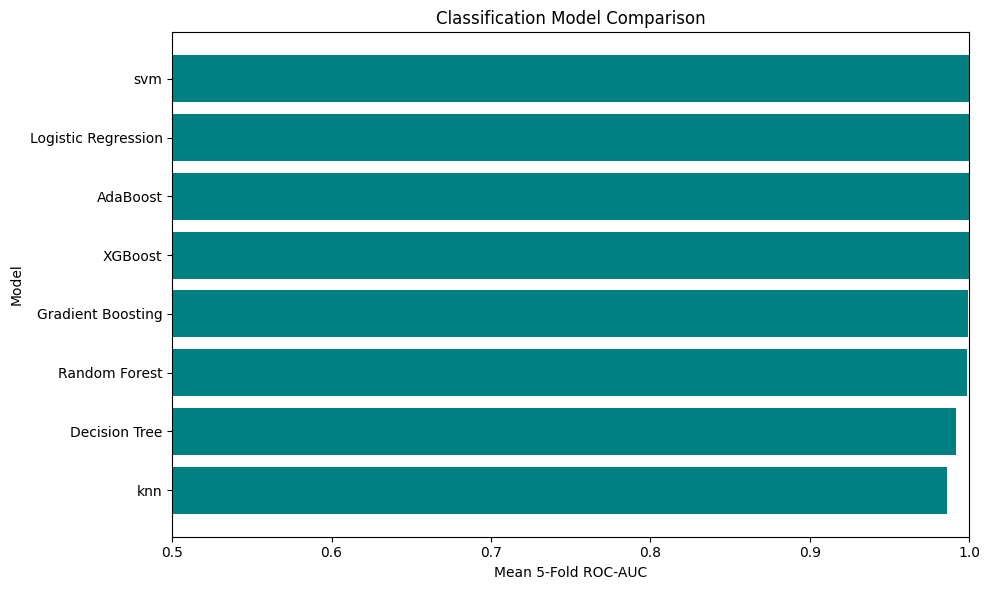

In [237]:
# Plot : Classification model comparison

plot_df = model_comparison.sort_values("CV ROC-AUC")

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Model"],
    plot_df["CV ROC-AUC"],
    color="teal"
)

plt.xlabel("Mean 5-Fold ROC-AUC")
plt.ylabel("Model")
plt.title("Classification Model Comparison")

plt.xlim(0.5, 1.0)

plt.tight_layout()
plt.show()

### Decision Tree Visualization



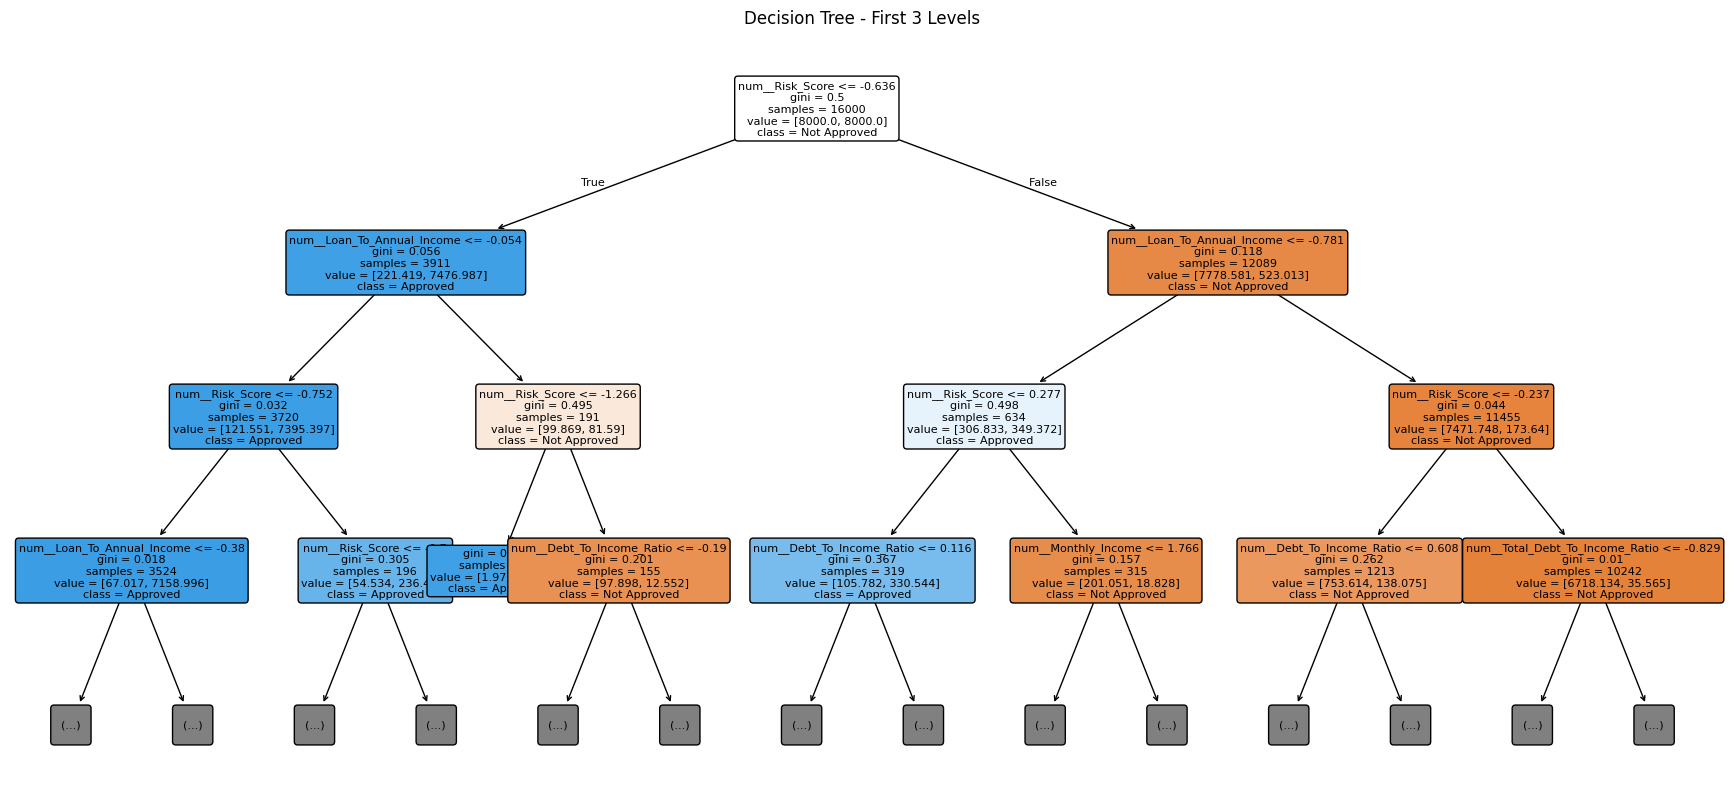

In [204]:
# Get the fitted preprocessing and tree model

tree_prep = decision_tree_pipeline.named_steps["preprocessing"]
tree_model = decision_tree_pipeline.named_steps["model"]

tree_feature_names = tree_prep.get_feature_names_out()

# Draw the Decision Tree

plt.figure(figsize=(22, 10))

plot_tree(
    tree_model,
    feature_names=tree_feature_names,
    class_names=["Not Approved", "Approved"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree - First 3 Levels")
plt.show()

### Random Forest Visualization

A Random Forest contains many decision trees, so the whole forest cannot be shown clearly in one diagram.Instead, I will draw one tree from the fitted Random Forest to show an example of the decision rules used by the ensemble.

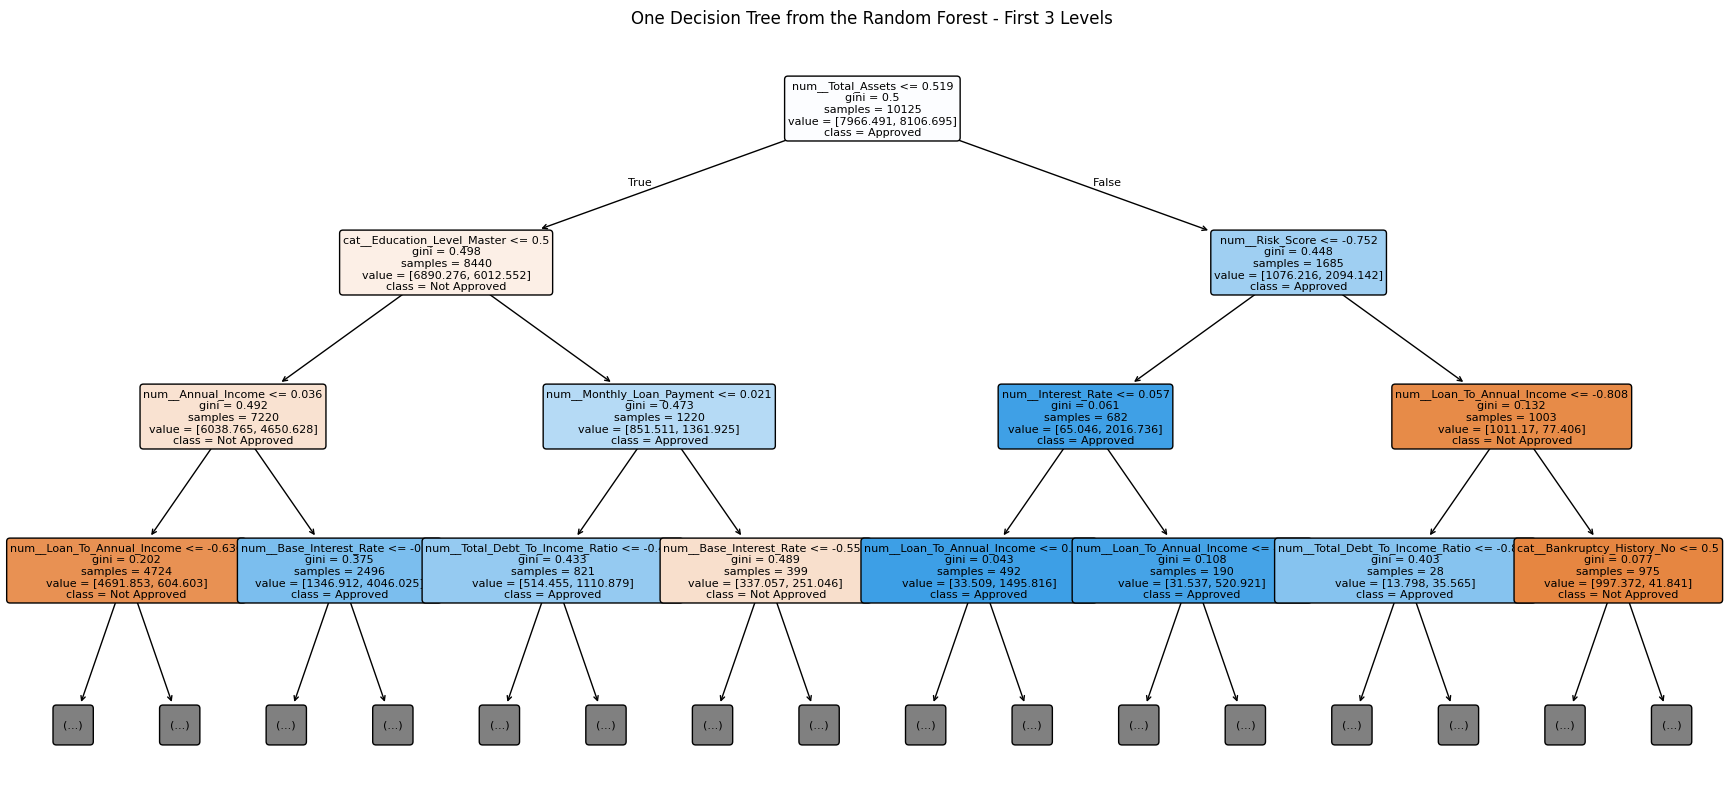

In [205]:
# Get the fitted preprocessing and Random Forest model

rf_prep = random_forest_pipeline.named_steps["preprocessing"]
rf_model_fitted = random_forest_pipeline.named_steps["model"]

rf_feature_names = rf_prep.get_feature_names_out()

# Select the first tree from the forest

one_tree = rf_model_fitted.estimators_[0]

# Draw one tree from the Random Forest

plt.figure(figsize=(22, 10))

plot_tree(
    one_tree,
    feature_names=rf_feature_names,
    class_names=["Not Approved", "Approved"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("One Decision Tree from the Random Forest - First 3 Levels")
plt.show()

## Hyperparameter Tuning

I will tune the Random Forest using GridSearchCV.

I choose Random Forest for tuning because it is an ensemble model that is relatively interpretable through feature importance and individual tree visualization.

I will test:
- number of trees
- maximum depth
- minimum samples per leaf

The tuning uses 5-fold stratified cross-validation and ROC-AUC.

In [206]:
# Create the Random Forest model for tuning

rf_model = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Create the Random Forest pipeline

rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", rf_model)
])

In [207]:
# Choose different values to test

rf_param_grid = {
    "model__n_estimators": [60, 100],
    "model__max_depth": [8, 12],
    "model__min_samples_leaf": [5, 10]
}

# Use GridSearchCV to find the best parameters

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    scoring="roc_auc",
    cv=cv5,
    n_jobs=-1,
    return_train_score=True
)

# Train the model and test the different parameter combinations

rf_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Annual_Income',
                                                                          'Credit_Score',
                                                                          'Experience',
                                                                          'Loan_Amount',
                                                                          'Loan_Duration',
                                                                          'Number_Of_Dependents',...
                                                                         ['Employment_Status',
                                                                          'Education_Level',
                                                                          'Marital_Status',
                                                                          'Home_Ownership_Status',
                                                                          'Bankruptcy_History',
                                                                          'Loan_Purpose'])])),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [8, 12],
                         'model__min_samples_leaf': [5, 10],
                         'model__n_estimators': [60, 100]},
             return_train_score=True, scoring='roc_auc')

This defines the Random Forest hyperparameter search: 60 or 100 trees, maximum depth 8 or 12, and minimum leaf size 5 or 10. GridSearchCV evaluates the combinations using 5-fold stratified cross-validation and ROC-AUC as the selection metric.

In [208]:
# Show the best parameters

print("Best parameters:")
print(rf_grid.best_params_)

Best parameters:
{'model__max_depth': 12, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}


In [209]:
# Show the best cross-validation ROC-AUC

print("Best mean CV ROC-AUC:")
print(round(rf_grid.best_score_, 4))

Best mean CV ROC-AUC:
0.9989


The best mean cross-validation ROC-AUC is 0.9989. This indicates the selected Random Forest configuration separates the two historical approval classes extremely well in cross-validation.

In [210]:
# Display the tuning results

tuning_results = pd.DataFrame(rf_grid.cv_results_)

tuning_results = tuning_results[
    [
        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__min_samples_leaf",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

display(tuning_results)

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,mean_test_score,std_test_score,rank_test_score
5,100,12,5,0.998876,0.000383,1
4,60,12,5,0.998820,0.000415,2
7,100,12,10,0.998682,0.000337,3
6,60,12,10,0.998604,0.000330,4
1,100,8,5,0.998530,0.000500,5
3,100,8,10,0.998377,0.000500,6
2,60,8,10,0.998376,0.000453,7
0,60,8,5,0.998351,0.000516,8


This table records all tested Random Forest configurations, their mean ROC-AUC, variation and rank. The best row has 100 trees, depth 12 and leaf size 5, with mean ROC-AUC = 0.998876. The results also show that increasing depth from 8 to 12 improved the tested configurations.


### CRISP-DM Summary: Modeling

- I used two regression models as classroom baselines and 8 classification models as the main approaches.

- The regression baselines were Simple Linear Regression and Multiple Linear Regression.

The classification models were ; Logistic Regression, Decision Tree, Random Forest, AdaBoost, Gradient Boosting , SVM, KNN and XGBoost.

I evaluated the classification models using 5-fold stratified cross-validation and several metrics. I also tuned the Random Forest using GridSearchCV before final test-set evaluation.

## Evaluation and Conclusion


## 5. Evaluation

 I will evaluate the final tuned Random Forest on the held-out test set.

For classification I will check:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion matrix
- ROC curve

For the regression baseline I will use a predicted versus actual scatter plot.I will also calculate the business cost proxy and check model performance across selected customer segments.

In [211]:
# Select the tuned Random Forest

final_model = rf_grid.best_estimator_

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

print("Final model selected: tuned Random Forest")


Final model selected: tuned Random Forest


I now use the tuned Random Forest to make predictions on the test set. The test data was not used to fit or tune the model, so it gives a more honest estimate of performance on unseen data.

In [212]:
# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 3))

# Calculate precision

precision = precision_score(y_test, y_pred)

print("Precision:", round(precision, 3))

# Calculate recall

recall = recall_score(y_test, y_pred)

print("Recall:", round(recall, 3))

# Calculate F1 score

f1 = f1_score(y_test, y_pred)

print("F1 Score:", round(f1, 3))

# Calculate ROC-AUC

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", round(roc_auc, 3))

Accuracy: 0.988
Precision: 0.966
Recall: 0.983
F1 Score: 0.975
ROC-AUC: 0.999


On the unseen test set, the tuned Random Forest achieved accuracy = 0.988, precision = 0.966, recall = 0.983, F1 = 0.975 and ROC-AUC = 0.999.

In [213]:
# Create a table with all the final test results

test_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Test Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

display(test_metrics.round(3))

,Metric,Test Value
0,Accuracy,0.988
1,Precision,0.966
2,Recall,0.983
3,F1,0.975
4,ROC-AUC,0.999


In [214]:
# Display the classification report tuned random foreest

print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.995     0.989     0.992      3044
           1      0.966     0.983     0.975       956

    accuracy                          0.988      4000
   macro avg      0.980     0.986     0.983      4000
weighted avg      0.988     0.988     0.988      4000



The classification report separates performance by class. For class 0, precision is 0.995, recall = 0.989 and F1 = 0.992 across = 3,044 test cases. For class 1, precision is = 0.966, recall = 0.983 and F1 = 0.975 across 956 test cases. This shows strong performance on both classes, including the smaller positive class.


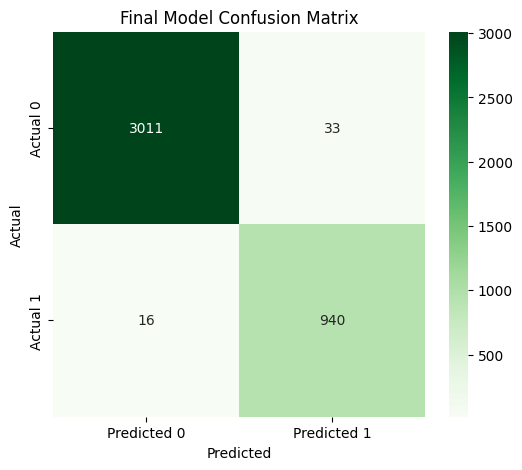

True Negative: 3011
False Positive: 33
False Negative: 16
True Positive: 940


In [215]:
# Plot 8: Confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

tn, fp, fn, tp = cm.ravel()

print("True Negative:", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive:", tp)


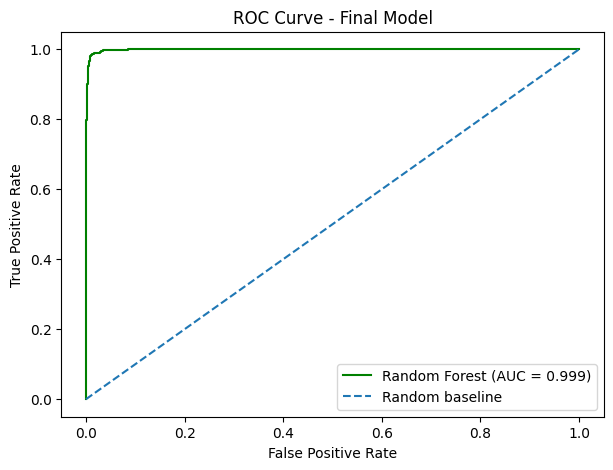

In [216]:
# Plot : ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_value = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    color="green",
    label=f"Random Forest (AUC = {auc_value:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Model")
plt.legend()
plt.show()


This plots the ROC curve for the final Random Forest and reports an AUC of about 0.999. A curve close to the upper left area indicates strong separation between the two historical classes across thresholds.

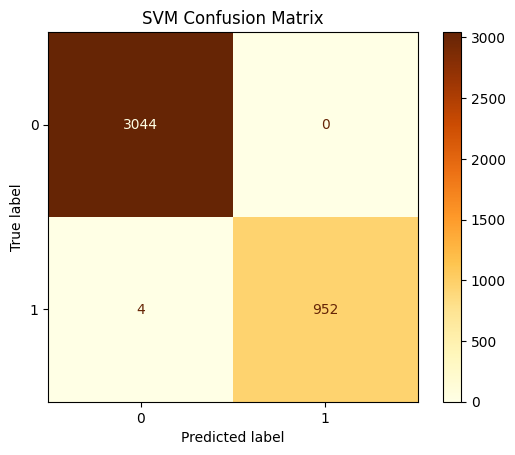

In [235]:
# SVM — Confusion Matrix

# Make predictions
svm_pred = svm_pipeline.predict(X_test)

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_pred,
    cmap="YlOrBr"
)

plt.title("SVM Confusion Matrix")
plt.show()

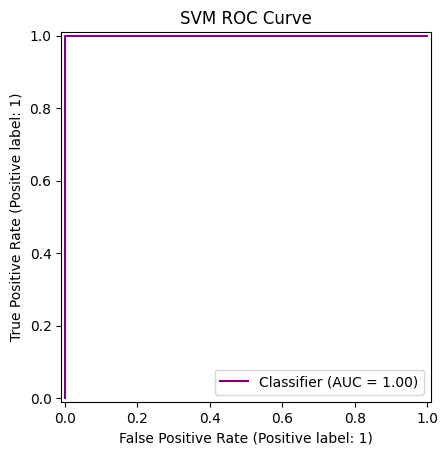

In [218]:
# Get predicted probabilities
svm_prob = svm_pipeline.predict_proba(X_test)[:, 1]

# Plot ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    svm_prob,
    color="purple"
)

plt.title("SVM ROC Curve")
plt.show()

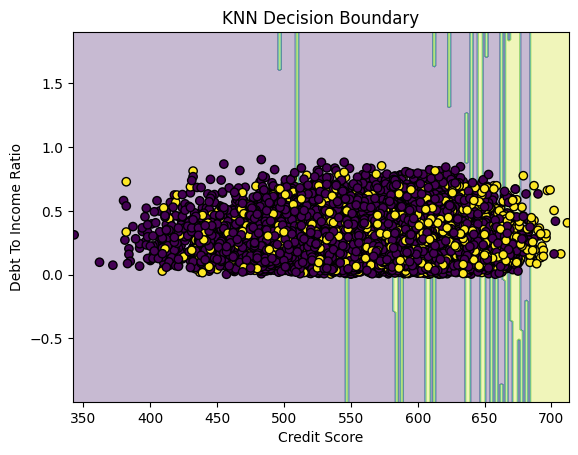

In [219]:
from sklearn.neighbors import KNeighborsClassifier

# Choose two features
features = ["Credit_Score", "Debt_To_Income_Ratio"]

X_2d = X_train[features]
y_2d = y_train

# Create KNN model
knn_2d = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_2d.fit(X_2d, y_2d)

# Create the grid
x_min = X_2d.iloc[:, 0].min() - 1
x_max = X_2d.iloc[:, 0].max() + 1

y_min = X_2d.iloc[:, 1].min() - 1
y_max = X_2d.iloc[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Predict for every point in the grid
Z = knn_2d.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot the actual data points
plt.scatter(
    X_2d.iloc[:, 0],
    X_2d.iloc[:, 1],
    c=y_2d,
    edgecolor="black"
)

plt.xlabel("Credit Score")
plt.ylabel("Debt To Income Ratio")
plt.title("KNN Decision Boundary")
plt.show()

This creates a two-feature KNN model using Credit_Score and Debt_To_Income_Ratio then plots its decision boundary.

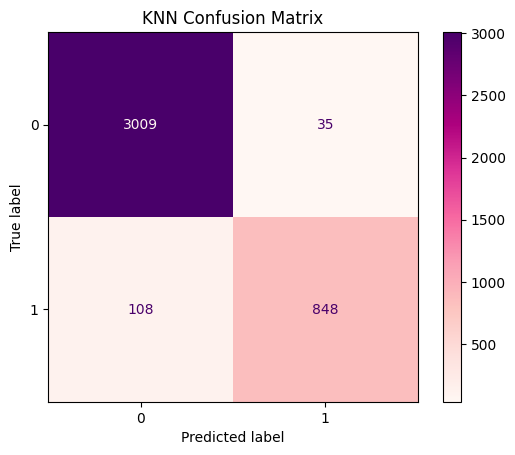

In [236]:
# Make predictions
knn_pred = knn_pipeline.predict(X_test)

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_pred,
    cmap="RdPu"
)

plt.title("KNN Confusion Matrix")
plt.show()

In [221]:
# Train the simple linear regression model

simple_regression.fit(
    X_train[["Credit_Score"]],
    y_train
)

# Train the multiple linear regression model

multiple_regression.fit(
    X_train[numeric_model_features],
    y_train
)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('model', LinearRegression())])

This fits the two regression baselines on the training data: simple regression using credit score and multiple regression using the numerical feature set. The returned Pipeline confirms median imputation, standardization and linear regression are connected in the model workflow.


In [222]:
# Make predictions using the simple model

simple_pred = simple_regression.predict(
    X_test[["Credit_Score"]]
)

# Make predictions using the multiple model

multiple_pred = multiple_regression.predict(
    X_test[numeric_model_features]
)

# Calculate metrics for the simple model

simple_mae = mean_absolute_error(y_test, simple_pred)
simple_rmse = mean_squared_error(y_test, simple_pred) ** 0.5
simple_r2 = r2_score(y_test, simple_pred)

print("Simple Linear Regression")
print("MAE:", round(simple_mae, 3))
print("RMSE:", round(simple_rmse, 3))
print("R2:", round(simple_r2, 3))


Simple Linear Regression
MAE: 0.357
RMSE: 0.422
R2: 0.02


On the data set test set, Simple Linear Regression gives MAE = 0.357, RMSE = 0.422 and R² = 0.020. This confirms that a single credit-score feature is not sufficient to explain the binary approval target well when treated as a continuous regression problem.


In [223]:
# Calculate metrics for the multiple model

multiple_mae = mean_absolute_error(y_test, multiple_pred)
multiple_rmse = mean_squared_error(y_test, multiple_pred) ** 0.5
multiple_r2 = r2_score(y_test, multiple_pred)

print("Multiple Linear Regression")
print("MAE:", round(multiple_mae, 3))
print("RMSE:", round(multiple_rmse, 3))
print("R2:", round(multiple_r2, 3))

Multiple Linear Regression
MAE: 0.162
RMSE: 0.204
R2: 0.77


Multiple Linear Regression gives test MAE = 0.162, RMSE = 0.204 and R² = 0.770. It improves over the simple regression baseline, but it remains a regression approximation.

In [224]:
# Compare both regression models

regression_results = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "MAE": [
        simple_mae,
        multiple_mae
    ],
    "RMSE": [
        simple_rmse,
        multiple_rmse
    ],
    "R2": [
        simple_r2,
        multiple_r2
    ]
})

display(regression_results.round(3))

,Model,MAE,RMSE,R2
0,Simple Linear Regression,0.357,0.422,0.02
1,Multiple Linear Regression,0.162,0.204,0.77


The regression table compares the two baseline regression models on the held out test data. Lower MAE and RMSE are better, while a higher R² means more variation in the binary target is explained.

These models are useful as baselines, but they are not the main solution because a binary approval decision is better treated as a classification problem.though multiple linear regression is better than a simple linear regression because it has a higher R2 of 0.77

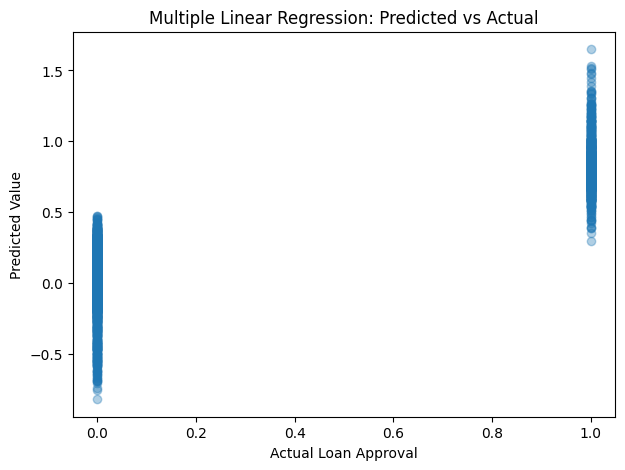

In [225]:
# Plot: Predicted versus actual values for Multiple Linear Regression

plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    multiple_pred,
    alpha=0.35
)

plt.xlabel("Actual Loan Approval")
plt.ylabel("Predicted Value")
plt.title("Multiple Linear Regression: Predicted vs Actual")

plt.show()

In [226]:
# Calculate the business-cost proxy

# Set the cost of each type of mistake

FP_COST = 50000
FN_COST = 8000

# Calculate the cost of the final model

business_cost = (fp * FP_COST) + (fn * FN_COST)

# Calculate the cost if we always deny

always_deny_cost = int(y_test.sum()) * FN_COST

print("Always deny cost:", always_deny_cost)

# Calculate the cost if we always approve

always_approve_cost = int((y_test == 0).sum()) * FP_COST

print("Final model cost:", business_cost)
print("Always deny cost:", always_deny_cost)
print("Always approve cost:", always_approve_cost)

Always deny cost: 7648000
Final model cost: 1778000
Always deny cost: 7648000
Always approve cost: 152200000


This converts the final model's errors into the assignment's business-cost proxy. With 33 false positives at $50,000 each and 16 false negatives at $8,000 each, the final model cost is $1,778,000. Always denying all 956 approved test applications would cost $7,648,000 under the proxy, while always approving all 3,044 non-approved applications would cost $152,200,000. These are scenario comparisons, not actual realised financial losses.


In [227]:
# Compare the three scenarios

cost_summary = pd.DataFrame({
    "Scenario": [
        "Final model",
        "Always deny",
        "Always approve"
    ],

    "False Positives": [
        fp,
        0,
        int((y_test == 0).sum())
    ],

    "False Negatives": [
        fn,
        int((y_test == 1).sum()),
        0
    ],

    "Proxy Cost ($)": [
        business_cost,
        always_deny_cost,
        always_approve_cost
    ]
})

display(cost_summary)

,Scenario,False Positives,False Negatives,Proxy Cost ($)
0,Final model,33,16,1778000
1,Always deny,0,956,7648000
2,Always approve,3044,0,152200000


In [228]:
# Check performance across selected customer segments
# Copy the test data

test_eval = X_test.copy()

test_eval["actual"] = y_test.values
test_eval["predicted"] = y_pred

# Divide customers into four income groups

test_eval["income_segment"] = pd.qcut(
    test_eval["Annual_Income"],
    q=4,
    duplicates="drop"
)

print(test_eval["income_segment"].value_counts())

income_segment
(14999.999, 30983.5]    1000
(30983.5, 47924.5]      1000
(47924.5, 73841.0]      1000
(73841.0, 300000.0]     1000
Name: count, dtype: int64


This creates four equally sized annual-income segments in the
4,000-row test set. Each segment contains 1,000 applications. The purpose is to check whether model performance changes across income levels.


In [229]:
# Divide customers into credit score groups

test_eval["credit_segment"] = pd.cut(
    test_eval["Credit_Score"],
    bins=[0, 579, 669, np.inf],
    labels=["Lower", "Middle", "Higher"]
)

print(test_eval["credit_segment"].value_counts())

# Create a list to store the results

segment_rows = []

credit_segment
Lower     2021
Middle    1955
Higher      24
Name: count, dtype: int64


This creates credit-score segments using the specified cutoffs. The test set contains 2,021 lower-score, 1,955 middle-score and only 24 higher-score applications.

In [230]:
 # Calculate model performance for each customer segment

for column in ["Employment_Status", "income_segment", "credit_segment"]:

    for group, data in test_eval.groupby(column, observed=False):

        if len(data) >= 30:

            accuracy = accuracy_score(
                data["actual"],
                data["predicted"]
            )

            precision = precision_score(
                data["actual"],
                data["predicted"],
                zero_division=0
            )

            recall = recall_score(
                data["actual"],
                data["predicted"],
                zero_division=0
            )

            segment_rows.append([
                column,
                str(group),
                len(data),
                accuracy,
                precision,
                recall
            ])

In [231]:
# Put the results into a DataFrame

segment_results = pd.DataFrame(
    segment_rows,
    columns=[
        "Segment Variable",
        "Segment",
        "Number of Applications",
        "Accuracy",
        "Precision",
        "Recall"
    ]
)

display(segment_results.round(3))

,Segment Variable,Segment,Number of Applications,Accuracy,Precision,Recall
0,Employment_Status,Employed,3402,0.988,0.963,0.988
1,Employment_Status,Self-Employed,311,0.977,0.987,0.927
2,Employment_Status,Unemployed,287,0.997,0.980,1.000
3,income_segment,"(14999.999, 30983.5]",1000,0.998,1.000,0.857
4,income_segment,"(30983.5, 47924.5]",1000,0.994,0.958,0.958
5,income_segment,"(47924.5, 73841.0]",1000,0.978,0.929,0.978
6,income_segment,"(73841.0, 300000.0]",1000,0.981,0.980,0.991
7,credit_segment,Lower,2021,0.993,0.990,0.975
8,credit_segment,Middle,1955,0.983,0.953,0.989


This extracts the post-preprocessing feature names and the Random Forest feature importance values, then sorts them.

 The top contributors in the model are Risk_Score (0.377), Loan_To_Annual_Income (0.134), Monthly_Income (0.093), Total_Debt_To_Income_Ratio (0.093), Annual_Income (0.082) and Payment_To_Monthly_Income (0.061).

 Feature importance means the model used these features heavily it does not prove they cause approval.

In [232]:
# Feature importance from the final Random Forest

prep = final_model.named_steps["preprocessing"]
model = final_model.named_steps["model"]

feature_names = prep.get_feature_names_out()

importance_table = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(importance_table.head(15))

,Feature,Importance
27,num__Risk_Score,0.376978
28,num__Loan_To_Annual_Income,0.133765
19,num__Monthly_Income,0.093127
26,num__Total_Debt_To_Income_Ratio,0.092685
1,num__Annual_Income,0.082422
30,num__Payment_To_Monthly_Income,0.061493
24,num__Interest_Rate,0.032908
4,num__Loan_Amount,0.013992
22,num__Net_Worth,0.013908
23,num__Base_Interest_Rate,0.013505


This table shows the processed features that contributed most to the Random Forest's decisions. Because categorical variables were one-hot encoded, some feature names include both the original variable and a category.



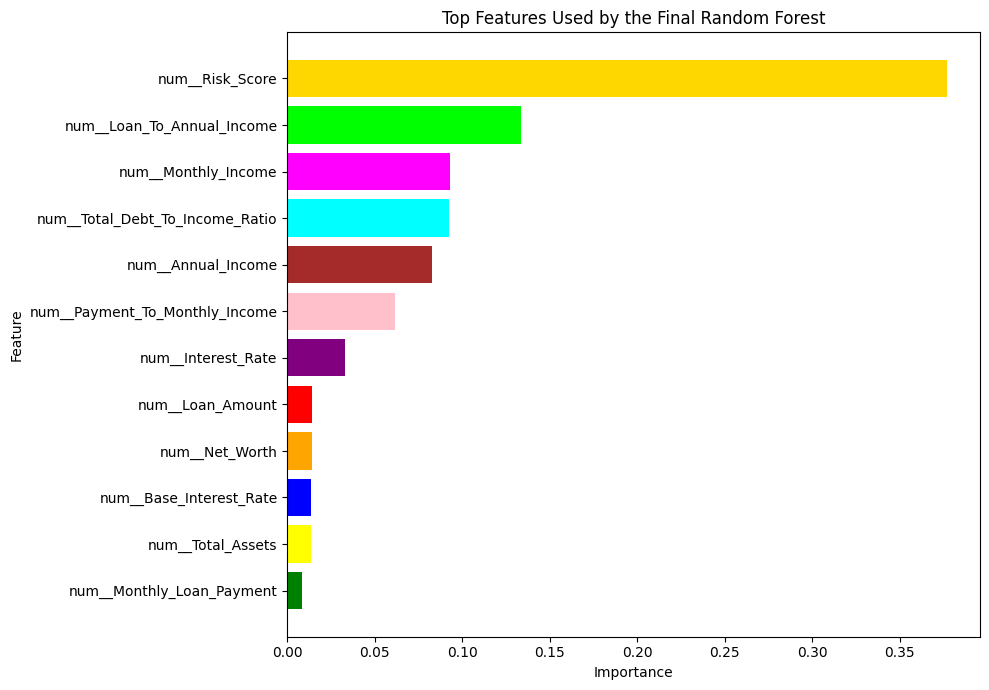

In [233]:
# Plot : Top feature importance

top_features = importance_table.head(12).sort_values("Importance")

plt.figure(figsize=(10, 7))

colors = [
    "green",
    "yellow",
    "blue",
    "orange",
    "red",
    "purple",
    "pink",
    "brown",
    "cyan",
    "magenta",
    "lime",
    "gold"
]

plt.barh(
    top_features["Feature"],
    top_features["Importance"],
    color=colors
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Features Used by the Final Random Forest")

plt.tight_layout()
plt.show()

This shows that the model relyes heavilly on risk score when making predictions

1. Business Understanding

The main objective of this project was to help loan officers make a consistent first-stage assessment when reviewing loan applications.

The project considered the following business costs:

- False approval: $50,000
- False denial: $8,000

Since the cost of a false approval is much higher than the cost of a false denial, accuracy alone is not enough to evaluate the models. I therefore considered several evaluation measures:

- Precision
- Recall
- F1-score
- Cost-sensitive measure
- Accuracy

The target variable, Loan_Approved, is binary because an applicant is either approved or not approved.

Therefore:

I used Classification as the main modelling approach and Regression  as a classroom baseline.


2. Data Understanding

I first examined the dataset to understand its structure, quality, and target variable. The dataset contained:

- 20,000 rows
- 35 columns
- 0 duplicate rows
- 2,804 missing values

The target variable, Loan_Approved, was not evenly distributed:

- 15,220 not-approved cases (76.1%)
- 4,780 approved cases (23.9%)

This shows that the dataset has a class imbalance, with more applicants being not approved than approved.

To better understand the data, I also examined:

- Distributions of numerical variables
- Relationships between categorical variables and the target
- Correlations between numerical variables
- Pairwise relationships between variables
- Statistical associations between variables

This analysis helped me understand the main patterns in the data and identify issues that needed to be considered during preprocessing and modelling.


3. Data Preparation

In this stage, I prepared the data for modelling by cleaning the variables and setting up the preprocessing steps.

The main steps were:

- Cleaned the Annual_Income variable.
- Separated the predictor variables (X) from the target variable (y).
- Created three new financial ratios to provide additional information for the models.
- Split the data into 80% training data and 20% testing data using stratification to maintain the same class distribution.
- For numerical variables, I used median imputation to handle missing values and then applied scaling.
- For categorical variables, I filled missing values and used one-hot encoding to convert them into numerical form.
-I used a ColumnTransformer and Pipeline to keep the preprocessing steps organized and help prevent data leakage.

I also compared mean and median imputation using cross-validation. Their results were very similar, so I chose median imputation for the final workflow.

4. Modelling

In this stage, I tested different machine learning models to find out which ones could best predict loan approval.

The models I tested were:

- 2 regression models as baseline models
- 8 classification models for the main prediction task

The classification models performed strongly during cross-validation.

I selected Random Forest for further tuning because:

- It can capture non-linear relationships in the data.
- It provides feature importance, which helps me understand which variables are important for the prediction.

After comparing the models,I used Random Forest for further tuning and evaluation.


5. Evaluation

After tuning the Random Forest model, I evaluated it on the unseen test set of 4,000 rows. The model achieved the following results:

Accuracy: 0.988
Precision: 0.966
Recall: 0.983
F1-score: 0.975
ROC-AUC: 0.999

The confusion matrix showed:

True Negatives (TN): 3,011
False Positives (FP): 33
False Negatives (FN): 16
True Positives (TP): 940

These results show that the model made relatively few incorrect predictions on the test data.

I also used the cost proxy provided in the assignment to understand the possible business impact:

Random Forest: $1,778,000
Always deny: $7,648,000
Always approve: $152,200,000


6. Interpretability and Risk

I also looked at the feature importance from the Random Forest model to understand which variables were most useful to the model when making predictions.

The variables with the highest feature importance were:

- Risk_Score: 0.377
- Loan_To_Annual_Income: 0.134
- Monthly_Income: 0.093
- Total_Debt_To_Income_Ratio: 0.093
- Annual_Income: 0.082
- Payment_To_Monthly_Income: 0.061

These values show how much the model relied on each variable when making predictions.

7. Main Limitation

The main limitation of this project is the definition of the target variable. The model predicts historical loan approval decisions, rather than whether a borrower actually defaulted on a loan.

This means that:

The model is learning from past approval decisions.
The $8,000 and $50,000 values are only business-cost proxies provided in the assignment.These amounts should not be treated as actual financial losses.The model should not be described as a fully validated loan default risk model because the dataset does not contain a true loan default outcome.

##OUTCOME
The tuned Random Forest model is  the best performing model in my study, achieving 98.8% accuracy, 97.5% F1-score, and 99.9% ROC-AUC on the test set.